# Notebook TFM: Predicción temprana de bancarrota empresarial

Este notebook recoge el flujo completo del trabajo empírico: carga del dataset, revisión de calidad de datos, análisis exploratorio, construcción de variables y ventanas temporales, entrenamiento de modelos clásicos de Machine Learning, entrenamiento de arquitecturas recurrentes de Deep Learning y evaluación comparativa final.

La versión se ha reorganizado visualmente con títulos, explicaciones y una celda inicial de librerías para facilitar la lectura, la revisión académica y la reproducibilidad del código.


## 0. Librerías y configuración del entorno

Esta celda centraliza las librerías utilizadas a lo largo del notebook. Se mantiene al inicio para mejorar la trazabilidad del código y facilitar la reproducción del análisis.


In [1]:
# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

# Manipulación de datos y cálculo numérico
import os
import time
import itertools
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Preprocesamiento, pipelines y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid

# Modelos clásicos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas de evaluación y visualización de resultados
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Concatenate,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Carpeta común para guardar figuras exportables a Overleaf
os.makedirs("figures", exist_ok=True)

print("Librerías cargadas correctamente.")
print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", len(tf.config.list_physical_devices("GPU")))


Librerías cargadas correctamente.
TensorFlow version: 2.21.0
GPUs disponibles: 0


## DATASET  BANKRUPTCY EE.UU

### Carga Dataset

Carga el dataset original, crea una copia de trabajo y realiza una primera comprobación de dimensiones y estructura.


In [2]:
# CARGA DATASET


# Cargar dataset original
df_original = pd.read_csv("american_bankruptcy_dataset.csv")

# Crear copia de trabajo
df = df_original.copy()

# Comprobación inicial
print("Dimensión del dataset original:", df_original.shape)
print("Dimensión de la copia de trabajo:", df.shape)

# Ver filas
df


Dimensión del dataset original: (78682, 23)
Dimensión de la copia de trabajo: (78682, 23)


,company_name,fyear,status_label,X1,X2,X3,X4,X5,X6,X7,...,X11,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup
0,C_1,1999.0,alive,511267.0,740998.000,833107.0,180447.000,18373.000,70658.000,89031.000,...,35.163,201026.000,128.348,1024333.000,372.7519,401483.000,1024333.000,935302.00,D,37
1,C_1,2000.0,alive,485856.0,701.854,713811.0,179987.000,18577.000,45.790,64367.000,...,18531.000,204065.000,115187.000,874255.000,377.1180,361642.000,874255.000,809888.00,D,37
2,C_1,2001.0,alive,436656.0,710199.000,526477.0,217699.000,22496.000,4711.000,27207.000,...,-58.939,139.603,77528.000,638721.000,364.5928,399964.000,638721.000,611514.00,D,37
3,C_1,2002.0,alive,396412.0,686.621,496747.0,164658.000,27172.000,3573.000,30745.000,...,-12.410,124106.000,66322.000,606337.000,143.3295,391633.000,606337.000,575592.00,D,37
4,C_1,2003.0,alive,432204.0,709.292,523302.0,248666.000,26.680,20811.000,47.491,...,3504.000,131884.000,104661.000,651.958,308.9071,407608.000,651.958,604467.00,D,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,2014.0,alive,233211.0,1099101.000,43338.0,184666.000,14094.000,31521.000,45615.000,...,25261.000,28095.000,22846.000,104223.000,756.4827,225887.000,104223.000,58608.00,E,44
78678,C_8971,2015.0,alive,105559.0,1865926.000,59184.0,770.103,42592.000,159541.000,202133.000,...,129688.000,157783.000,54611.000,291153.000,527575.0000,880327.000,291153.000,89.02,E,44
78679,C_8971,2016.0,alive,63971.0,1746235.000,69074.0,683985.000,65057.000,13.994,79051.000,...,-1442.000,156341.000,42467.000,169858.000,578.8868,770.233,169858.000,90807.00,E,44
78680,C_8971,2017.0,alive,135207.0,1736.110,66527.0,694035.000,65.330,3841.000,69171.000,...,-20401.000,135941.000,27217.000,161884.000,412.6241,776697.000,161884.000,92713.00,E,44


### Convertir Status_Label En Numérica

Transforma la variable objetivo `status_label` en una variable binaria numérica: empresa quebrada y empresa activa.


In [3]:
# CONVERTIR STATUS_LABEL EN NUMÉRICA

df["status_label"] = df["status_label"].map({
    "failed": 1,
    "alive": 0
})

# Comprobar que se ha creado correctamente
print(df[["status_label"]].head())

# Ver distribución
print(df["status_label"].value_counts())


   status_label
0             0
1             0
2             0
3             0
4             0
status_label
0    73462
1     5220
Name: count, dtype: int64


### Celda 3: Bloque de análisis

Muestra el DataFrame de trabajo para revisar visualmente las primeras variables y registros cargados.


In [4]:
df


,company_name,fyear,status_label,X1,X2,X3,X4,X5,X6,X7,...,X11,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup
0,C_1,1999.0,0,511267.0,740998.000,833107.0,180447.000,18373.000,70658.000,89031.000,...,35.163,201026.000,128.348,1024333.000,372.7519,401483.000,1024333.000,935302.00,D,37
1,C_1,2000.0,0,485856.0,701.854,713811.0,179987.000,18577.000,45.790,64367.000,...,18531.000,204065.000,115187.000,874255.000,377.1180,361642.000,874255.000,809888.00,D,37
2,C_1,2001.0,0,436656.0,710199.000,526477.0,217699.000,22496.000,4711.000,27207.000,...,-58.939,139.603,77528.000,638721.000,364.5928,399964.000,638721.000,611514.00,D,37
3,C_1,2002.0,0,396412.0,686.621,496747.0,164658.000,27172.000,3573.000,30745.000,...,-12.410,124106.000,66322.000,606337.000,143.3295,391633.000,606337.000,575592.00,D,37
4,C_1,2003.0,0,432204.0,709.292,523302.0,248666.000,26.680,20811.000,47.491,...,3504.000,131884.000,104661.000,651.958,308.9071,407608.000,651.958,604467.00,D,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,2014.0,0,233211.0,1099101.000,43338.0,184666.000,14094.000,31521.000,45615.000,...,25261.000,28095.000,22846.000,104223.000,756.4827,225887.000,104223.000,58608.00,E,44
78678,C_8971,2015.0,0,105559.0,1865926.000,59184.0,770.103,42592.000,159541.000,202133.000,...,129688.000,157783.000,54611.000,291153.000,527575.0000,880327.000,291153.000,89.02,E,44
78679,C_8971,2016.0,0,63971.0,1746235.000,69074.0,683985.000,65057.000,13.994,79051.000,...,-1442.000,156341.000,42467.000,169858.000,578.8868,770.233,169858.000,90807.00,E,44
78680,C_8971,2017.0,0,135207.0,1736.110,66527.0,694035.000,65.330,3841.000,69171.000,...,-20401.000,135941.000,27217.000,161884.000,412.6241,776697.000,161884.000,92713.00,E,44


### Revisión De Nulos Y Filas Duplicadas

Comprueba la presencia de valores nulos y filas duplicadas antes de continuar con el análisis.


In [5]:
# REVISIÓN DE NULOS Y FILAS DUPLICADAS

# Comprobar número total de valores nulos
print("Total de valores nulos en el dataset:", df.isnull().sum().sum())

# Comprobar filas duplicadas
duplicados = df.duplicated().sum()

print("Número de filas duplicadas:", duplicados)

# Mostrar dimensiones actuales del dataset
print("Dimensión actual del dataset:", df.shape)


Total de valores nulos en el dataset: 0
Número de filas duplicadas: 0
Dimensión actual del dataset: (78682, 23)


### Revisión Tipos De Variables Y Estructura Del Dataset

Revisa los tipos de variables, el número de columnas por tipo y la estructura general del dataset.


In [6]:
# REVISIÓN TIPOS DE VARIABLES Y ESTRUCTURA DEL DATASET


# Tipos de datos
print("Tipos de variables:")
display(df.dtypes)

# Número de variables por tipo
print("\nNúmero de variables por tipo:")
display(df.dtypes.value_counts())

# Listado de columnas
print("\nColumnas del dataset:")
print(df.columns.tolist())


Tipos de variables:


company_name        str
fyear           float64
status_label      int64
X1              float64
X2              float64
X3              float64
X4              float64
X5              float64
X6              float64
X7              float64
X8              float64
X9              float64
X10             float64
X11             float64
X12             float64
X13             float64
X14             float64
X15             float64
X16             float64
X17             float64
X18             float64
Division            str
MajorGroup        int64
dtype: object


Número de variables por tipo:


float64    19
str         2
int64       2
Name: count, dtype: int64


Columnas del dataset:
['company_name', 'fyear', 'status_label', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'Division', 'MajorGroup']


### Conversión Variable Temporal Fyear

Convierte la variable temporal `fyear` a entero y verifica el rango temporal disponible.


In [7]:
# CONVERSIÓN VARIABLE TEMPORAL FYEAR


# Convertir fyear de float a int
df["fyear"] = df["fyear"].astype(int)

# Comprobar el cambio
print("Tipo de fyear después de la conversión:")
print(df["fyear"].dtype)

print("\nRango temporal del dataset:")
print(df["fyear"].min(), "-", df["fyear"].max())

print("\nNúmero de años disponibles:")
print(df["fyear"].nunique())


Tipo de fyear después de la conversión:
int64

Rango temporal del dataset:
1999 - 2018

Número de años disponibles:
20


### Distribución Variable Objetivo

Analiza la distribución absoluta y porcentual de la variable objetivo para identificar el desbalanceo de clases.


In [8]:
# DISTRIBUCIÓN VARIABLE OBJETIVO


print("Distribución absoluta de status_label:")
print(df["status_label"].value_counts())

print("\nDistribución porcentual de status_label:")
print((df["status_label"].value_counts(normalize=True) * 100).round(2))


Distribución absoluta de status_label:
status_label
0    73462
1     5220
Name: count, dtype: int64

Distribución porcentual de status_label:
status_label
0    93.37
1     6.63
Name: proportion, dtype: float64


### Celda 8: Bloque de análisis

Calcula magnitudes básicas del dataset: número de observaciones empresa-año, empresas únicas y años disponibles.


In [9]:
n_obs = df.shape[0]
n_empresas = df["company_name"].nunique()
n_años = df["fyear"].nunique()

print("Número de observaciones empresa-año:", n_obs)
print("Número de empresas únicas:", n_empresas)
print("Número de años:", n_años)


Número de observaciones empresa-año: 78682
Número de empresas únicas: 8971
Número de años: 20


## RESUMEN

In [10]:
resumen_dataset = pd.DataFrame({
    "Elemento": [
        "Observaciones empresa-año",
        "Empresas únicas",
        "Periodo temporal",
        "Número de años",
        "Variables totales",
        "Variables financieras",
        "Variables sectoriales",
        "Valores nulos",
        "Filas duplicadas"
    ],
    "Valor": [
        df.shape[0],
        df["company_name"].nunique(),
        f"{df['fyear'].min()}-{df['fyear'].max()}",
        df["fyear"].nunique(),
        df.shape[1],
        len([col for col in df.columns if col.startswith("X")]),
        2,
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

display(resumen_dataset)


,Elemento,Valor
0,Observaciones empresa-año,78682
1,Empresas únicas,8971
2,Periodo temporal,1999-2018
3,Número de años,20
4,Variables totales,23
5,Variables financieras,18
6,Variables sectoriales,2
7,Valores nulos,0
8,Filas duplicadas,0


### Distribución Temporal De Observaciones Y Quiebras

Estudia la distribución temporal de observaciones y quiebras por ejercicio fiscal.


In [40]:
# DISTRIBUCIÓN TEMPORAL DE OBSERVACIONES Y QUIEBRAS


resumen_temporal = df.groupby("fyear").agg(
    observaciones=("status_label", "count"),
    empresas_vivas=("status_label", lambda x: (x == 0).sum()),
    empresas_quebradas=("status_label", "sum")
).reset_index()

resumen_temporal["tasa_quiebra_%"] = (
    resumen_temporal["empresas_quebradas"] / resumen_temporal["observaciones"] * 100
).round(2)

display(resumen_temporal)


,fyear,observaciones,empresas_vivas,empresas_quebradas,tasa_quiebra_%
0,1999,5308,4928,380,7.16
1,2000,5226,4822,404,7.73
2,2001,4897,4483,414,8.45
3,2002,4651,4237,414,8.90
4,2003,4417,4002,415,9.40
5,2004,4348,3944,404,9.29
6,2005,4205,3826,379,9.01
7,2006,4128,3762,366,8.87
8,2007,4009,3673,336,8.38
9,2008,3857,3573,284,7.36


### Separación De Variables Identificativas, Predictoras Y Objetivo

Separa variables identificativas, variables predictoras y variable objetivo para preparar el modelado posterior.


In [67]:
# SEPARACIÓN DE VARIABLES IDENTIFICATIVAS, PREDICTORAS Y OBJETIVO

# Variable objetivo
target = "status_label"

# Variables identificativas / no predictoras
variables_identificativas = ["company_name"]

# Variable temporal: se usará para análisis y división temporal, no como predictor inicial
variable_temporal = ["fyear"]

# Variables financieras predictoras
variables_financieras = sorted(
    [col for col in df.columns if col.startswith("X") and col != "X17"],
    key=lambda x: int(x.replace("X", ""))
)

# Variables sectoriales / categóricas
variables_sectoriales = ["Division", "MajorGroup"]

# Resumen
print("Variable objetivo:")
print(target)

print("\nVariables identificativas:")
print(variables_identificativas)

print("\nVariable temporal:")
print(variable_temporal)

print("\nVariables financieras predictoras:")
print(variables_financieras)

print("\nVariables sectoriales:")
print(variables_sectoriales)

print("\nNúmero de variables financieras:", len(variables_financieras))
print("Número de variables sectoriales:", len(variables_sectoriales))


Variable objetivo:
status_label

Variables identificativas:
['company_name']

Variable temporal:
['fyear']

Variables financieras predictoras:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X18']

Variables sectoriales:
['Division', 'MajorGroup']

Número de variables financieras: 17
Número de variables sectoriales: 2


### Análisis Variables Financieras

Analiza la composición y ordenación de las variables financieras X1-X18.


In [45]:
# ANÁLISIS VARIABLES FINANCIERAS

df[variables_financieras].describe().T


,count,mean,std,min,25%,50%,75%,max
X1,78682.0,213314.084193,7.016291e+05,-2.498000e+03,1272.0000,22016.5000,153994.000000,31322583.0
X2,78682.0,599470.892747,2.065452e+06,7.000000e-03,3282.5250,43266.5000,329362.000000,67234944.0
X3,78682.0,379774.455090,2.021659e+06,-3.666450e+05,1439.1000,21044.5000,180821.500000,163245615.0
X4,78682.0,150843.340375,7.115052e+05,-2.300000e+01,0.0000,500.0000,16010.500000,20687082.0
X5,78682.0,24715.653499,9.778169e+04,0.000000e+00,74.4000,1216.0000,12344.750000,4440438.0
X6,78682.0,44261.768582,2.240017e+05,-5.043795e+06,-767.7500,303.0000,19097.750000,9783515.0
X7,78682.0,69421.150571,2.847994e+05,-4.512135e+06,-9.0000,1121.9000,33256.750000,12566722.0
X8,78682.0,172375.674452,6.007523e+05,-4.367571e+06,355.4325,11459.5000,109900.000000,27864399.0
X9,78682.0,51021.655540,2.204076e+05,0.000000e+00,0.0000,675.0000,16771.750000,11918508.0
X10,78682.0,123397.132227,4.877100e+05,7.000000e-03,958.0750,10866.0000,69280.500000,27869687.0


### Comprobación variable X14 y X17

In [46]:
# Comprobamos si X14 y X17 son exactamente iguales
son_iguales = np.allclose(df["X14"], df["X17"], equal_nan=True)

print("¿X14 y X17 son iguales?:", son_iguales)
print("Diferencia máxima absoluta:", (df["X14"] - df["X17"]).abs().max())
print("Correlación X14-X17:", df[["X14", "X17"]].corr().iloc[0, 1])

¿X14 y X17 son iguales?: True
Diferencia máxima absoluta: 0.0
Correlación X14-X17: 1.0


### Estadíaticos de las variables financieras

In [47]:
tabla_estadisticos = df[variables_financieras].describe().T

tabla_estadisticos = tabla_estadisticos.rename(columns={
    "count": "N",
    "mean": "Media",
    "std": "Desv. típica",
    "min": "Mínimo",
    "25%": "P25",
    "50%": "Mediana",
    "75%": "P75",
    "max": "Máximo"
})

tabla_estadisticos = tabla_estadisticos.round(2)

print(tabla_estadisticos.to_latex(
    index=True,
    float_format="%.2f"
))


\begin{tabular}{lrrrrrrrr}
\toprule
 & N & Media & Desv. típica & Mínimo & P25 & Mediana & P75 & Máximo \\
\midrule
X1 & 78682.00 & 213314.08 & 701629.10 & -2498.00 & 1272.00 & 22016.50 & 153994.00 & 31322583.00 \\
X2 & 78682.00 & 599470.89 & 2065451.51 & 0.01 & 3282.52 & 43266.50 & 329362.00 & 67234944.00 \\
X3 & 78682.00 & 379774.46 & 2021659.41 & -366645.00 & 1439.10 & 21044.50 & 180821.50 & 163245615.00 \\
X4 & 78682.00 & 150843.34 & 711505.23 & -23.00 & 0.00 & 500.00 & 16010.50 & 20687082.00 \\
X5 & 78682.00 & 24715.65 & 97781.69 & 0.00 & 74.40 & 1216.00 & 12344.75 & 4440438.00 \\
X6 & 78682.00 & 44261.77 & 224001.73 & -5043795.00 & -767.75 & 303.00 & 19097.75 & 9783515.00 \\
X7 & 78682.00 & 69421.15 & 284799.37 & -4512135.00 & -9.00 & 1121.90 & 33256.75 & 12566722.00 \\
X8 & 78682.00 & 172375.67 & 600752.29 & -4367571.00 & 355.43 & 11459.50 & 109900.00 & 27864399.00 \\
X9 & 78682.00 & 51021.66 & 220407.62 & 0.00 & 0.00 & 675.00 & 16771.75 & 11918508.00 \\
X10 & 78682.00 & 123397.

### Boxplot variables financieras


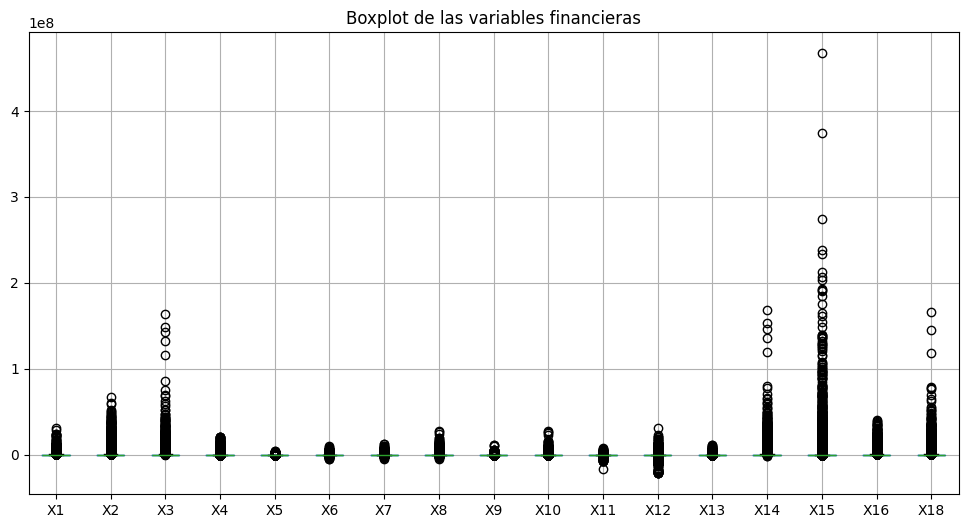

In [49]:
plt.figure(figsize=(12, 6))
df[variables_financieras].boxplot()
plt.title("Boxplot de las variables financieras")
plt.show()


### Distribución Empresas

Representa la distribución de empresas activas y quebradas para documentar gráficamente el desbalanceo.


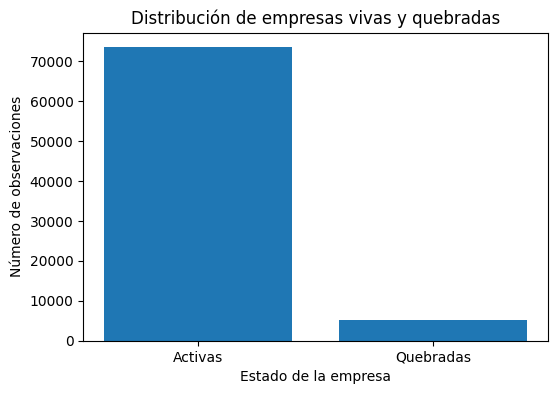

,Estado,Observaciones,Porcentaje
0,Activas,73462,93.37
1,Quebradas,5220,6.63


In [50]:
# DISTRIBUCIÓN EMPRESAS

# Conteo y porcentaje de clases
conteo_clases = df["status_label"].value_counts().sort_index()
porcentaje_clases = (df["status_label"].value_counts(normalize=True).sort_index() * 100).round(2)

# Etiquetas
etiquetas = ["Activas", "Quebradas"]

# Gráfico
plt.figure(figsize=(6, 4))
plt.bar(etiquetas, conteo_clases.values)

plt.title("Distribución de empresas vivas y quebradas")
plt.xlabel("Estado de la empresa")
plt.ylabel("Número de observaciones")

plt.show()

# Tabla debajo del gráfico
resumen_clases = pd.DataFrame({
    "Estado": etiquetas,
    "Observaciones": conteo_clases.values,
    "Porcentaje": porcentaje_clases.values
})

display(resumen_clases)


### Resumen Por Año

Resume la evolución anual de observaciones y quiebras, base del análisis temporal posterior.


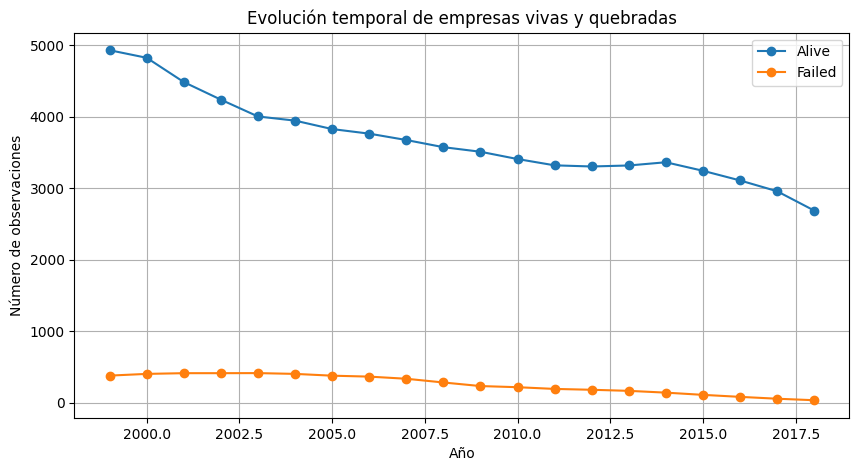

,Alive,Failed
fyear,,
1999,4928,380
2000,4822,404
2001,4483,414
2002,4237,414
2003,4002,415
2004,3944,404
2005,3826,379
2006,3762,366
2007,3673,336


In [51]:

# Resumen por año
resumen_anual = df.groupby("fyear")["status_label"].value_counts().unstack()

# Renombrar columnas
resumen_anual.columns = ["Alive", "Failed"]

# Gráfico
plt.figure(figsize=(10, 5))

plt.plot(resumen_anual.index, resumen_anual["Alive"], marker="o", label="Alive")
plt.plot(resumen_anual.index, resumen_anual["Failed"], marker="o", label="Failed")

plt.title("Evolución temporal de empresas vivas y quebradas")
plt.xlabel("Año")
plt.ylabel("Número de observaciones")
plt.legend()
plt.grid(True)

plt.show()

# Tabla resumen debajo
display(resumen_anual)


### Empresas Quebradas Por Año

Genera visualizaciones de la evolución temporal de empresas activas y quebradas.


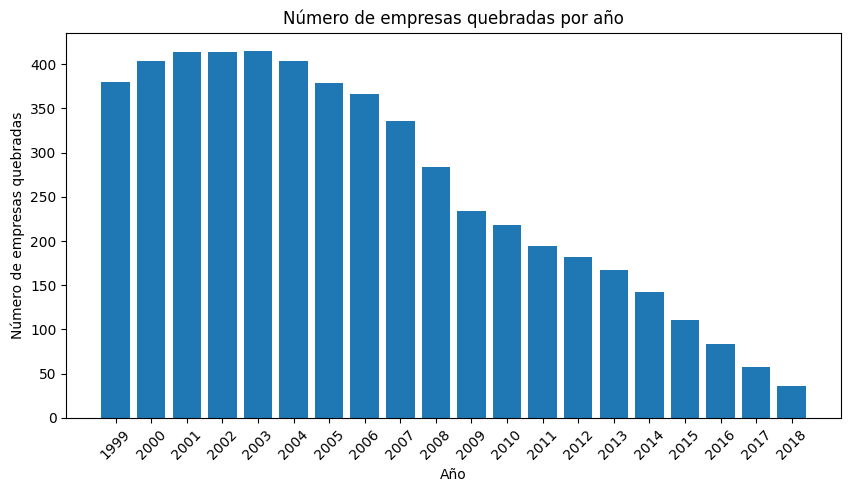

,fyear,empresas_quebradas
0,1999,380
1,2000,404
2,2001,414
3,2002,414
4,2003,415
5,2004,404
6,2005,379
7,2006,366
8,2007,336
9,2008,284


In [52]:
# Empresas quebradas por año
quiebras_anuales = df[df["status_label"] == 1].groupby("fyear").size()

# Gráfico
plt.figure(figsize=(10, 5))
plt.bar(quiebras_anuales.index, quiebras_anuales.values)

plt.title("Número de empresas quebradas por año")
plt.xlabel("Año")
plt.ylabel("Número de empresas quebradas")
plt.xticks(quiebras_anuales.index, rotation=45)

plt.show()

# Tabla debajo
display(quiebras_anuales.reset_index(name="empresas_quebradas"))


### Porcentaje De Quiebras Por Año

Calcula y representa el porcentaje anual de quiebras para observar cambios en el riesgo a lo largo del tiempo.


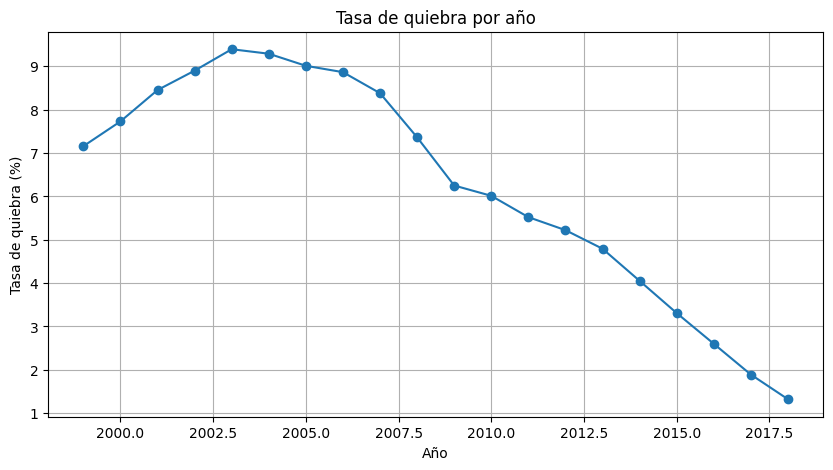

,fyear,tasa_quiebra_%
0,1999,7.16
1,2000,7.73
2,2001,8.45
3,2002,8.90
4,2003,9.40
5,2004,9.29
6,2005,9.01
7,2006,8.87
8,2007,8.38
9,2008,7.36


In [19]:
# PORCENTAJE DE QUIEBRAS POR AÑO

# Calcular tasa de quiebra por año
tasa_quiebra = df.groupby("fyear")["status_label"].mean() * 100

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(tasa_quiebra.index, tasa_quiebra.values, marker="o")

plt.title("Tasa de quiebra por año")
plt.xlabel("Año")
plt.ylabel("Tasa de quiebra (%)")
plt.grid(True)

plt.show()

# Tabla debajo
display(tasa_quiebra.round(2).reset_index(name="tasa_quiebra_%"))


### Observaciones Por Año

Analiza el volumen de observaciones disponibles por año fiscal.


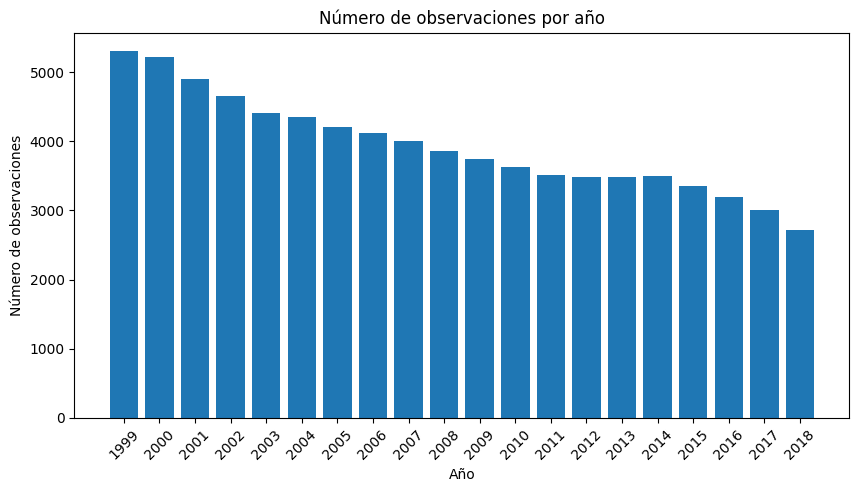

,fyear,observaciones
0,1999,5308
1,2000,5226
2,2001,4897
3,2002,4651
4,2003,4417
5,2004,4348
6,2005,4205
7,2006,4128
8,2007,4009
9,2008,3857


In [20]:
# Observaciones por año
observaciones_anuales = df.groupby("fyear").size()

# Gráfico
plt.figure(figsize=(10, 5))
plt.bar(observaciones_anuales.index, observaciones_anuales.values)

plt.title("Número de observaciones por año")
plt.xlabel("Año")
plt.ylabel("Número de observaciones")
plt.xticks(observaciones_anuales.index, rotation=45)

plt.show()

# Tabla debajo
display(observaciones_anuales.reset_index(name="observaciones"))


### Distribución De Empresas Por Sector

Estudia la distribución de empresas por división sectorial.


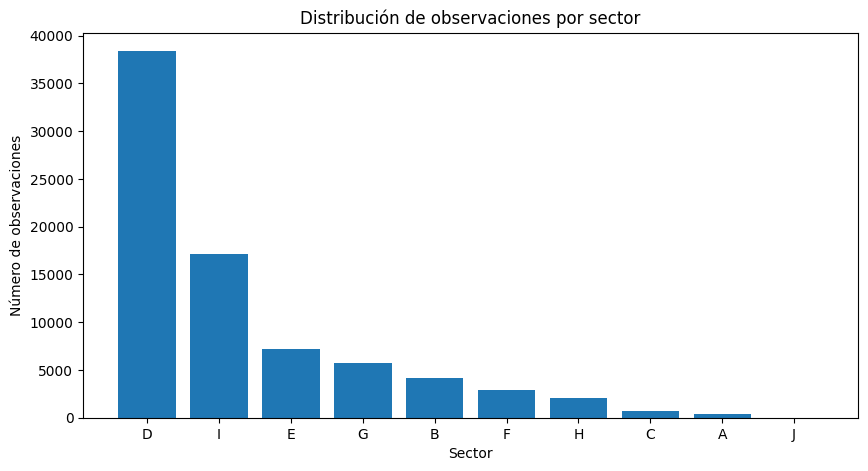

,Division,observaciones
0,D,38384
1,I,17148
2,E,7203
3,G,5695
4,B,4181
5,F,2939
6,H,2060
7,C,721
8,A,338
9,J,13


In [21]:
# DISTRIBUCIÓN DE EMPRESAS POR SECTOR

# Conteo por Division
division_counts = df["Division"].value_counts()

# Gráfico
plt.figure(figsize=(10, 5))
plt.bar(division_counts.index, division_counts.values)

plt.title("Distribución de observaciones por sector")
plt.xlabel("Sector")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=0)

plt.show()

# Tabla debajo
display(division_counts.reset_index(name="observaciones"))


### Tasa De Quiebra Por Sector

Calcula la tasa de quiebra por división sectorial para identificar diferencias de riesgo entre sectores.


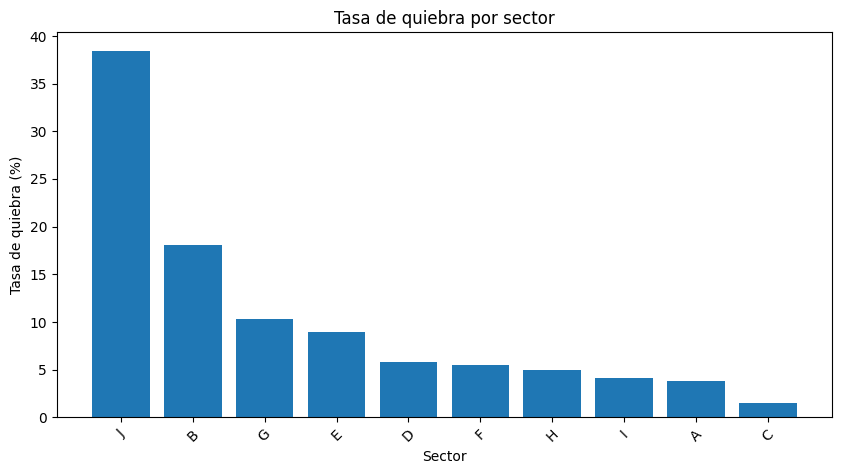

,Division,tasa_quiebra_%
0,J,38.46
1,B,18.11
2,G,10.34
3,E,8.90
4,D,5.83
5,F,5.51
6,H,4.90
7,I,4.11
8,A,3.85
9,C,1.53


In [22]:
# TASA DE QUIEBRA POR SECTOR

# Tasa de quiebra por sector
tasa_quiebra_sector = df.groupby("Division")["status_label"].mean() * 100

# Ordenar de mayor a menor
tasa_quiebra_sector = tasa_quiebra_sector.sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10, 5))
plt.bar(tasa_quiebra_sector.index, tasa_quiebra_sector.values)

plt.title("Tasa de quiebra por sector")
plt.xlabel("Sector")
plt.ylabel("Tasa de quiebra (%)")
plt.xticks(rotation=45)

plt.show()

# Tabla debajo
display(tasa_quiebra_sector.round(2).reset_index(name="tasa_quiebra_%"))


### Distribución De Observaciones Por Major_Group

Analiza la distribución de observaciones por `MajorGroup`.


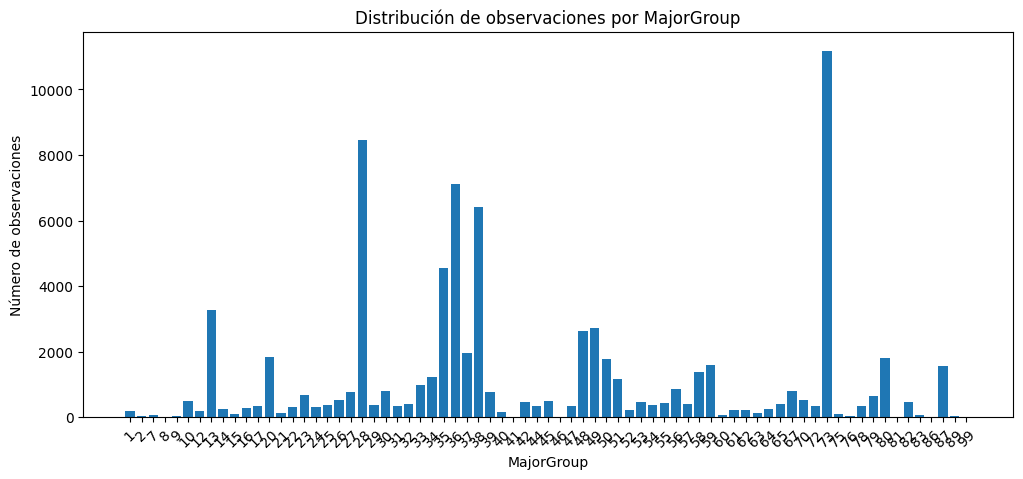

,MajorGroup,observaciones
0,1,185
1,2,35
2,7,74
3,8,20
4,9,24
...,...,...
68,83,62
69,86,4
70,87,1578
71,89,31


In [23]:
# DISTRIBUCIÓN DE OBSERVACIONES POR MAJOR_GROUP

# Conteo por MajorGroup
major_counts = df["MajorGroup"].value_counts().sort_index()

# Gráfico
plt.figure(figsize=(12, 5))
plt.bar(major_counts.index.astype(str), major_counts.values)

plt.title("Distribución de observaciones por MajorGroup")
plt.xlabel("MajorGroup")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)

plt.show()

# Tabla debajo
display(major_counts.reset_index(name="observaciones"))


### Tasa De Quiebra Por Major_Group

Calcula la tasa de quiebra por `MajorGroup`.


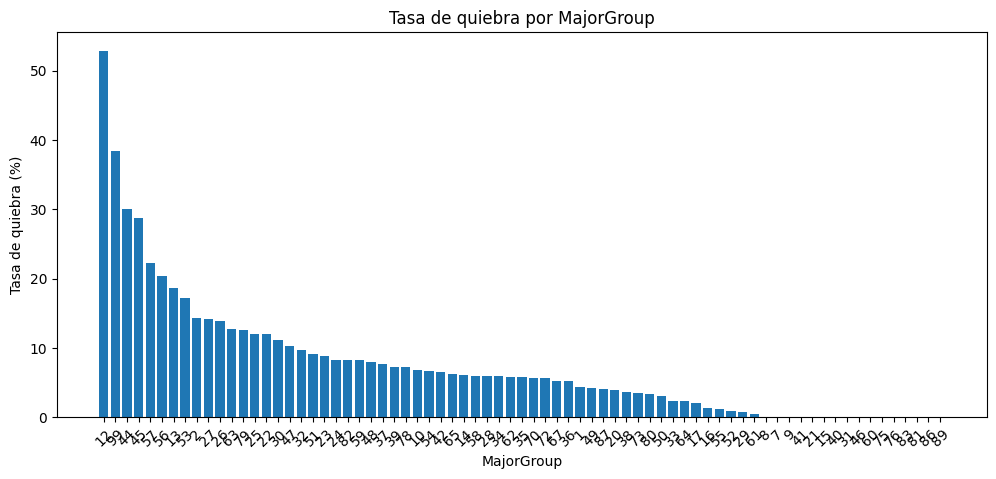

,MajorGroup,tasa_quiebra_%
0,12,52.91
1,99,38.46
2,44,30.03
3,45,28.83
4,57,22.25
...,...,...
68,76,0.00
69,83,0.00
70,81,0.00
71,86,0.00


In [23]:
# TASA DE QUIEBRA POR MAJOR_GROUP

# Tasa de quiebra por MajorGroup
tasa_quiebra_major = df.groupby("MajorGroup")["status_label"].mean() * 100

# Ordenar de mayor a menor
tasa_quiebra_major = tasa_quiebra_major.sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 5))
plt.bar(tasa_quiebra_major.index.astype(str), tasa_quiebra_major.values)

plt.title("Tasa de quiebra por MajorGroup")
plt.xlabel("MajorGroup")
plt.ylabel("Tasa de quiebra (%)")
plt.xticks(rotation=45)

plt.show()

# Tabla debajo
display(tasa_quiebra_major.round(2).reset_index(name="tasa_quiebra_%"))


### Matriz Correlación Entre Variables

Construye la matriz de correlación entre variables financieras.


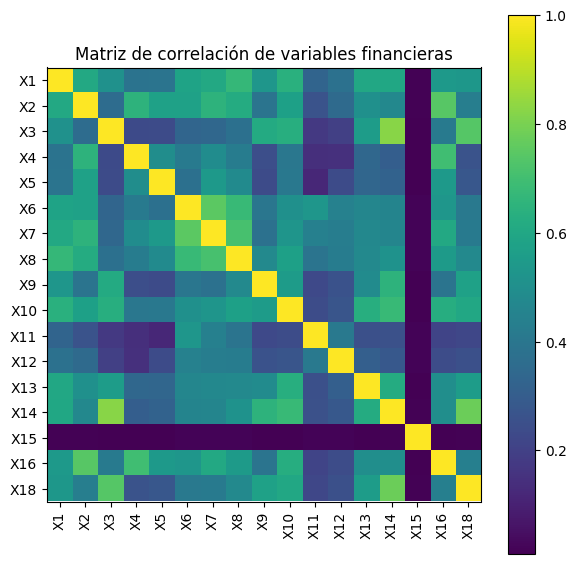

In [53]:
# MATRIZ CORRELACIÓN ENTRE VARIABLES

# Matriz de correlación
correlacion = df[variables_financieras].corr()

plt.figure(figsize=(7, 7))
plt.imshow(correlacion)

plt.colorbar()
plt.xticks(range(len(variables_financieras)), variables_financieras, rotation=90)
plt.yticks(range(len(variables_financieras)), variables_financieras)

plt.title("Matriz de correlación de variables financieras")

plt.show()


### Mediana De Las Variables Financieras

Analiza las medianas de las variables financieras como medida robusta frente a valores extremos.


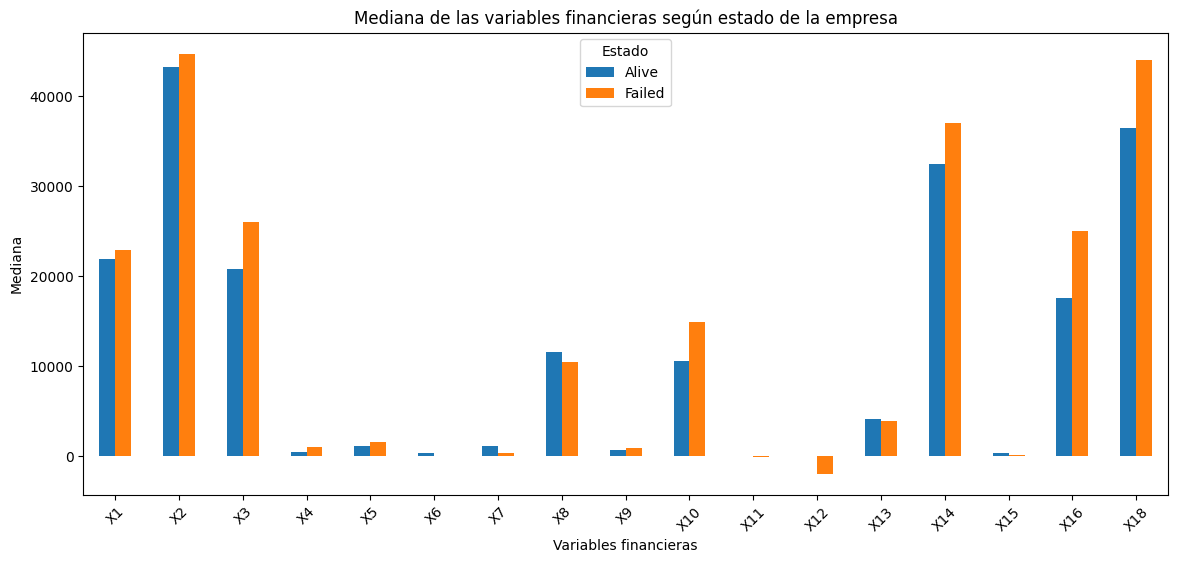

,Alive,Failed
X1,21959.50000,22899.0000
X2,43180.50000,44726.0000
X3,20765.00000,26021.5000
X4,472.65000,1023.5000
X5,1193.52500,1630.0000
X6,350.60000,3.6550
X7,1187.38800,320.8900
X8,11549.00000,10475.5000
X9,661.80000,898.0000
X10,10585.50000,14879.0000


In [54]:
# MEDIANA DE LAS VARIABLES FINANCIERAS

# Mediana de cada variable financiera según estado
medianas_por_estado = df.groupby("status_label")[variables_financieras].median().T

# Renombrar columnas
medianas_por_estado.columns = ["Alive", "Failed"]

# Gráfico
medianas_por_estado.plot(kind="bar", figsize=(14, 6))

plt.title("Mediana de las variables financieras según estado de la empresa")
plt.xlabel("Variables financieras")
plt.ylabel("Mediana")
plt.xticks(rotation=45)
plt.legend(title="Estado")

plt.show()

# Tabla debajo
display(medianas_por_estado)


### Mediana Por Estado

Compara medianas de variables financieras entre empresas activas y quebradas.


In [55]:

# Mediana por estado
medianas = df.groupby("status_label")[variables_financieras].median().T

medianas.columns = ["Alive", "Failed"]
medianas["Diferencia"] = medianas["Failed"] - medianas["Alive"]
medianas["Diferencia_%"] = (medianas["Diferencia"] / medianas["Alive"] * 100).round(2)

# Ordenar por diferencia porcentual en valor absoluto
medianas = medianas.sort_values("Diferencia_%", key=abs, ascending=False)

display(medianas)


,Alive,Failed,Diferencia,Diferencia_%
X12,-0.77100,-1917.5000,-1916.72900,248602.98
X11,48.45200,-70.8695,-119.32150,-246.27
X4,472.65000,1023.5000,550.85000,116.55
X6,350.60000,3.6550,-346.94500,-98.96
X7,1187.38800,320.8900,-866.49800,-72.98
X15,398.46345,177.1866,-221.27685,-55.53
X16,17548.50000,24997.5000,7449.00000,42.45
X10,10585.50000,14879.0000,4293.50000,40.56
X5,1193.52500,1630.0000,436.47500,36.57
X9,661.80000,898.0000,236.20000,35.69


### Análisis Bivariante: Variables Financieras Vs Variable Objetivo

Genera boxplots por variable financiera y estado de la empresa para estudiar diferencias bivariantes.


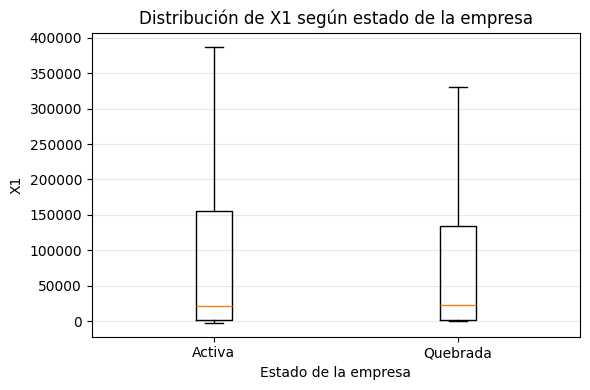

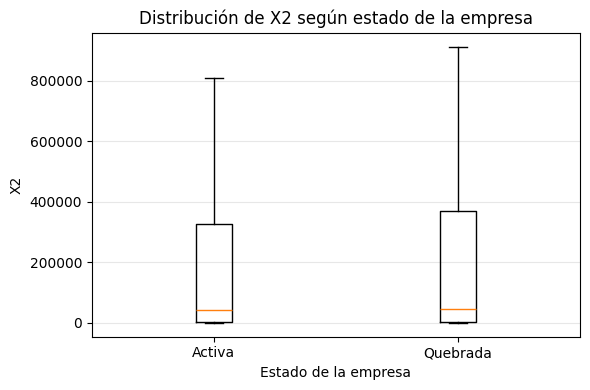

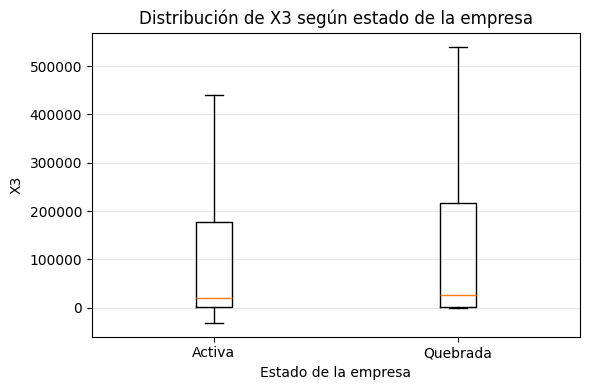

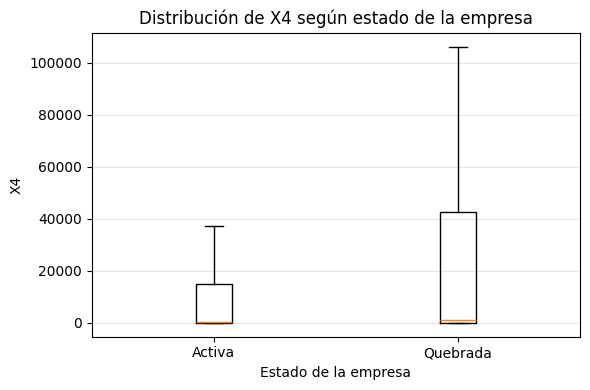

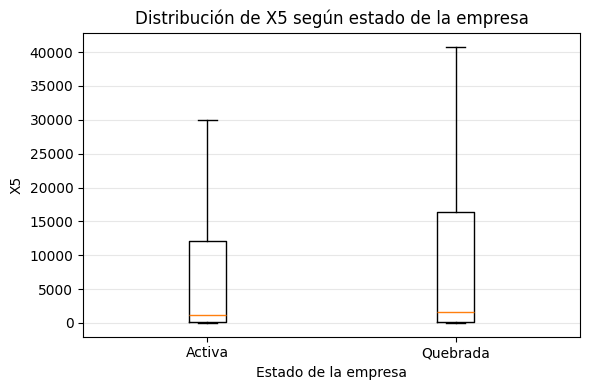

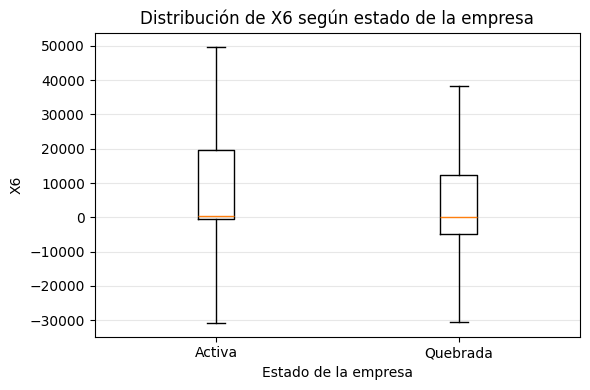

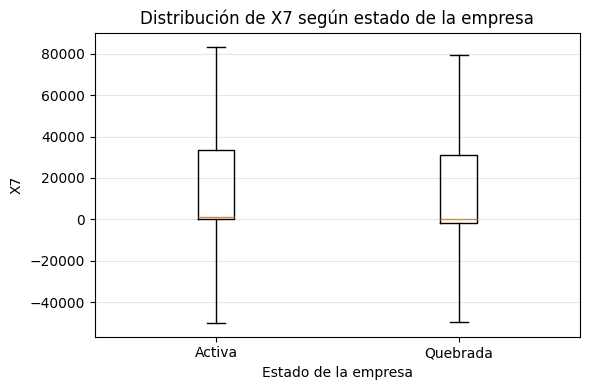

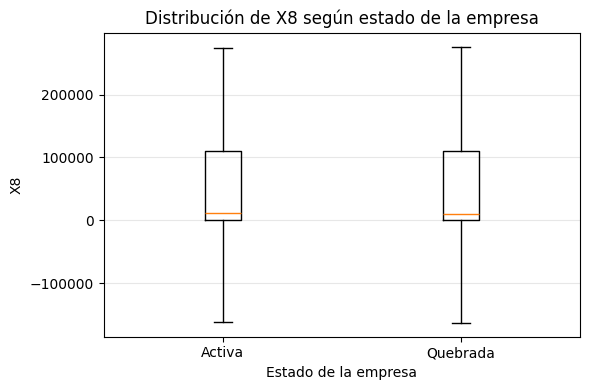

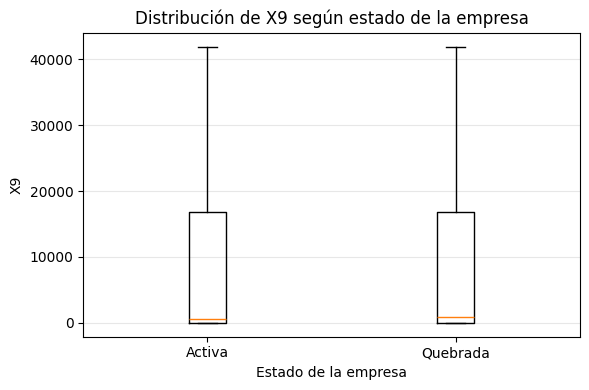

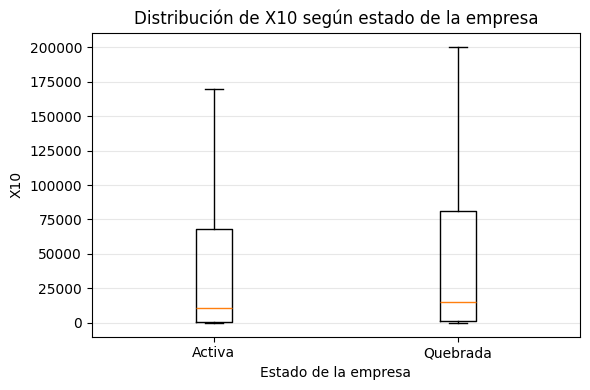

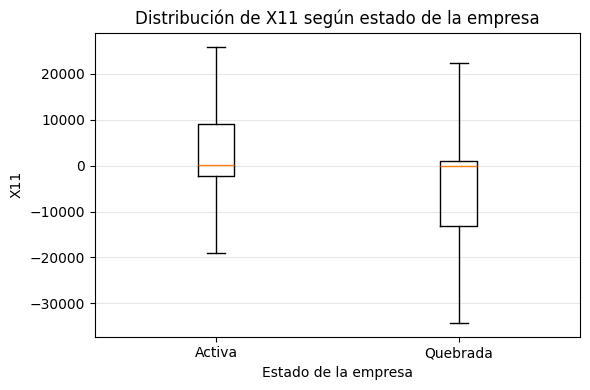

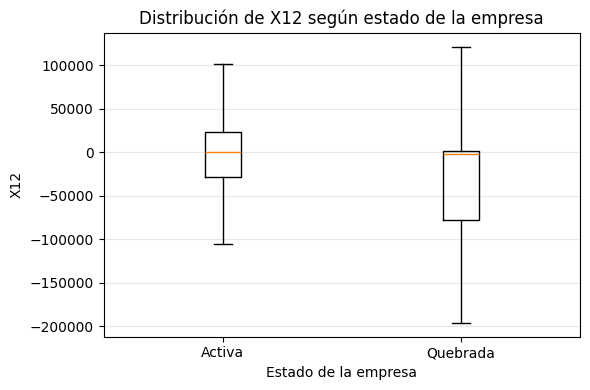

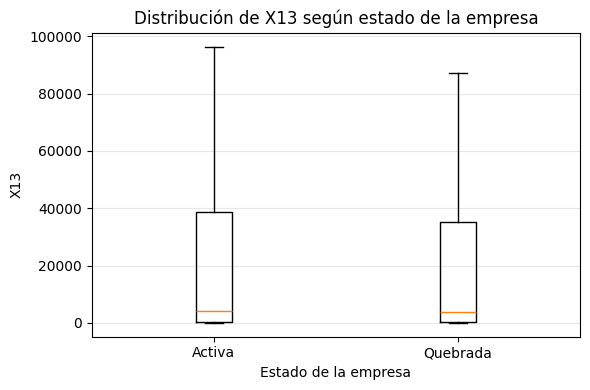

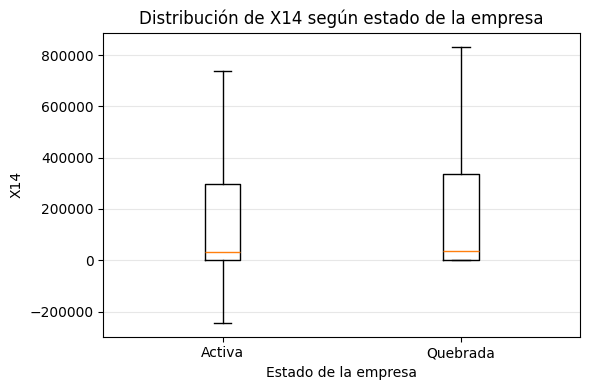

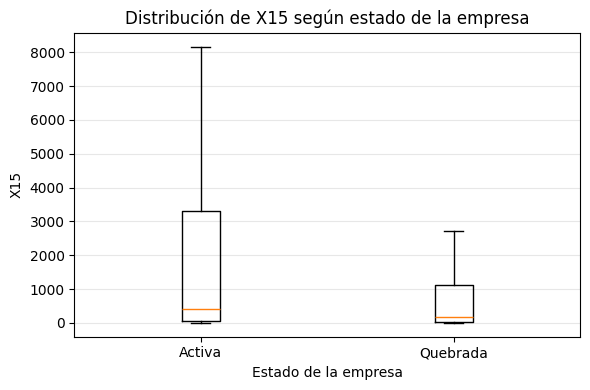

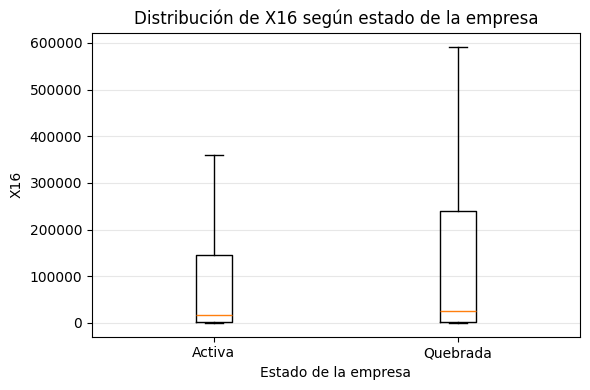

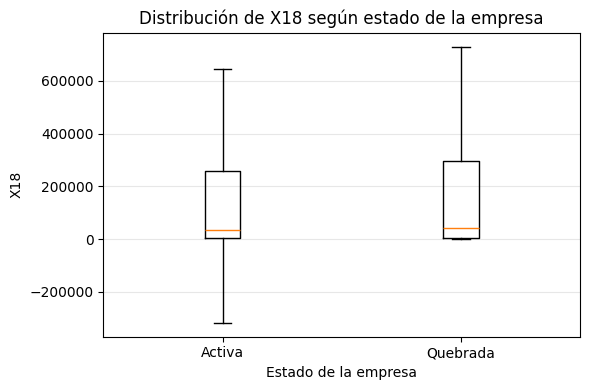

In [56]:
# ============================================================
# ANÁLISIS BIVARIANTE: VARIABLES FINANCIERAS VS VARIABLE OBJETIVO
# ============================================================

# Este análisis compara la distribución de cada variable financiera
# entre empresas activas (0) y quebradas (1).
# Permite observar diferencias en mediana, dispersión y valores extremos.

# Etiquetas más interpretables para los gráficos
df_bivariante = df.copy()
df_bivariante["Estado empresa"] = df_bivariante["status_label"].map({
    0: "Activa",
    1: "Quebrada"
})

# Carpeta para guardar gráficos
os.makedirs("figures", exist_ok=True)

# ------------------------------------------------------------
# Boxplots individuales por variable financiera
# ------------------------------------------------------------

for variable in variables_financieras:

    plt.figure(figsize=(6, 4))

    datos_activa = df_bivariante[df_bivariante["status_label"] == 0][variable].dropna()
    datos_quebrada = df_bivariante[df_bivariante["status_label"] == 1][variable].dropna()

    plt.boxplot(
    [datos_activa, datos_quebrada],
    tick_labels=["Activa", "Quebrada"],
    showfliers=False
    )


    plt.title(f"Distribución de {variable} según estado de la empresa")
    plt.xlabel("Estado de la empresa")
    plt.ylabel(variable)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"figures/boxplot_{variable}_estado.png", dpi=300, bbox_inches="tight")
    plt.show()


### Tabla Resumen Bivariante Por Variable Financiera

Complementa el análisis bivariante con visualizaciones adicionales de las variables financieras.


In [57]:
# ============================================================
# TABLA RESUMEN BIVARIANTE POR VARIABLE FINANCIERA
# ============================================================

resumen_bivariante = []

for variable in variables_financieras:

    activa = df[df["status_label"] == 0][variable].dropna()
    quebrada = df[df["status_label"] == 1][variable].dropna()

    resumen_bivariante.append({
        "Variable": variable,
        "Mediana Activa": activa.median(),
        "Mediana Quebrada": quebrada.median(),
        "Media Activa": activa.mean(),
        "Media Quebrada": quebrada.mean(),
        "Desv. típica Activa": activa.std(),
        "Desv. típica Quebrada": quebrada.std(),
        "IQR Activa": activa.quantile(0.75) - activa.quantile(0.25),
        "IQR Quebrada": quebrada.quantile(0.75) - quebrada.quantile(0.25),
        "Diferencia medianas": quebrada.median() - activa.median()
    })

tabla_bivariante = pd.DataFrame(resumen_bivariante)

tabla_bivariante["Diferencia % mediana"] = (
    tabla_bivariante["Diferencia medianas"] / tabla_bivariante["Mediana Activa"].replace(0, np.nan) * 100
).round(2)

tabla_bivariante = tabla_bivariante.sort_values(
    by="Diferencia % mediana",
    key=lambda x: x.abs(),
    ascending=False
)

display(tabla_bivariante)

tabla_bivariante.to_csv("tabla_analisis_bivariante_financieras_status.csv", index=False)


,Variable,Mediana Activa,Mediana Quebrada,Media Activa,Media Quebrada,Desv. típica Activa,Desv. típica Quebrada,IQR Activa,IQR Quebrada,Diferencia medianas,Diferencia % mediana
11,X12,-0.77100,-1917.5000,57616.899900,-89031.090834,8.139748e+05,7.928961e+05,51779.0000,80112.82500,-1916.72900,248602.98
10,X11,48.45200,-70.8695,16433.087859,-20640.530336,1.876466e+05,3.053847e+05,11257.0000,14177.00000,-119.32150,-246.27
3,X4,472.65000,1023.5000,145140.990609,231093.535493,6.731960e+05,1.116292e+06,14883.5000,42674.50000,550.85000,116.55
5,X6,350.60000,3.6550,46163.102839,17503.949195,2.261057e+05,1.899731e+05,20134.2075,17251.00000,-346.94500,-98.96
6,X7,1187.38800,320.8900,70597.849666,52861.252313,2.868479e+05,2.536712e+05,33408.1710,32616.25000,-866.49800,-72.98
14,X15,398.46345,177.1866,471665.893296,118628.959034,5.259858e+06,2.051254e+06,3249.1824,1076.69045,-221.27685,-55.53
15,X16,17548.50000,24997.5000,345537.726599,438673.134846,1.330949e+06,1.704825e+06,143352.0000,237028.00000,7449.00000,42.45
9,X10,10585.50000,14879.0000,124268.783299,111130.229720,4.939401e+05,3.894376e+05,67356.2500,79533.22500,4293.50000,40.56
4,X5,1193.52500,1630.0000,24165.974317,32451.387612,9.672272e+04,1.113473e+05,11962.2500,16299.33500,436.47500,36.57
8,X9,661.80000,898.0000,52239.203262,33886.887203,2.259835e+05,1.150643e+05,16761.0000,16856.86925,236.20000,35.69


### Figura Conjunta: Boxplots Bivariantes Variables Seleccionadas

Guarda figuras del análisis exploratorio para su incorporación en Overleaf.


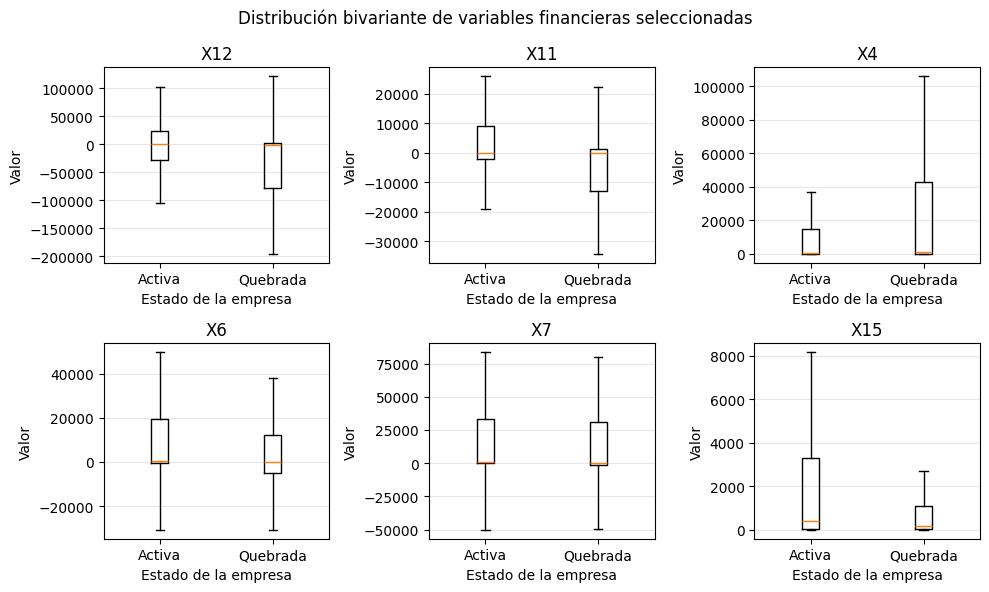

In [64]:
# ============================================================
# FIGURA CONJUNTA: BOXPLOTS BIVARIANTES VARIABLES SELECCIONADAS
# ============================================================


os.makedirs("figures", exist_ok=True)

top_variables = tabla_bivariante.head(6)["Variable"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, variable in zip(axes, top_variables):

    datos_activa = df[df["status_label"] == 0][variable].dropna()
    datos_quebrada = df[df["status_label"] == 1][variable].dropna()

    ax.boxplot(
        [datos_activa, datos_quebrada],
        tick_labels=["Activa", "Quebrada"],
        showfliers=False
    )

    ax.set_title(variable)
    ax.set_xlabel("Estado de la empresa")
    ax.set_ylabel("Valor")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribución bivariante de variables financieras seleccionadas", fontsize=12)
plt.tight_layout()

plt.savefig(
    "figures/boxplots_bivariante_top_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Correlación Entre Variables Financieras Y Status_Label

Calcula la correlación entre las variables financieras y la variable objetivo.


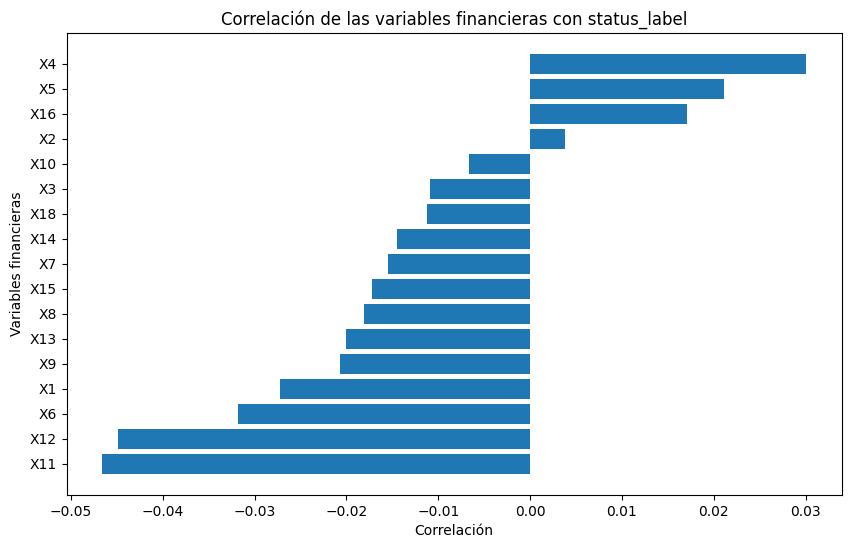

,Variable financiera,Correlación con quiebra
0,X11,-0.046635
1,X12,-0.044871
2,X6,-0.031842
3,X1,-0.027273
4,X9,-0.020723
5,X13,-0.020083
6,X8,-0.018109
7,X15,-0.017193
8,X7,-0.015500
9,X14,-0.014488


In [90]:
# CORRELACIÓN ENTRE VARIABLES FINANCIERAS Y STATUS_LABEL


# Correlación con status_label
correlacion_status = df[variables_financieras + ["status_label"]].corr()["status_label"]
correlacion_status = correlacion_status.drop("status_label")
correlacion_status = correlacion_status.sort_values()

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(correlacion_status.index, correlacion_status.values)

plt.title("Correlación de las variables financieras con status_label")
plt.xlabel("Correlación")
plt.ylabel("Variables financieras")

plt.show()

# Tabla de correlaciones
tabla_correlacion = (
    correlacion_status
    .reset_index()
    .rename(columns={
        "index": "Variable financiera",
        target: "Correlación con quiebra"
    })
)

display(tabla_correlacion)


### PARTICIÓN, SUBMUESTREO Y NORMALIZACIÓN

### Configuración Inicial Para Modelado

Define la configuración inicial para el modelado: variables, semilla, métricas y modelos necesarios.


In [68]:
# ============================================================
# CONFIGURACIÓN INICIAL PARA MODELADO
# ============================================================


# Modelos clásicos

# Pipeline, escalado y validación

# Métricas

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Variable objetivo
target = "status_label"

# Variable de empresa y variable temporal
id_col = "company_name"
time_col = "fyear"

print("Variable objetivo:", target)
print("Variable identificativa:", id_col)
print("Variable temporal:", time_col)
print("Variables financieras usadas:")
print(variables_financieras)
print("Número de variables financieras:", len(variables_financieras))


Variable objetivo: status_label
Variable identificativa: company_name
Variable temporal: fyear
Variables financieras usadas:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X18']
Número de variables financieras: 17


### Función Para Crear Ventanas Temporales

Ordena los datos por empresa y año para construir correctamente la información temporal.


In [69]:
# ============================================================
# FUNCIÓN PARA CREAR VENTANAS TEMPORALES
# ============================================================

def crear_ventanas_temporales(
    df,
    id_col,
    time_col,
    feature_cols,
    target_col,
    window_size=4
):
    """
    Crea ventanas temporales por empresa.

    Ejemplo:
    Si window_size = 4, cada observación usará 4 años consecutivos
    de variables financieras para una empresa.

    Devuelve:
    - X_ml: formato 2D para modelos clásicos.
            Ejemplo con WL=4: 4 años x 18 variables = 72 columnas.
    - X_dl: formato 3D para Deep Learning.
            Formato: samples, timesteps, features.
    - y: variable objetivo.
    - info: empresa y año objetivo de cada ventana.
    """

    X_ml = []
    X_dl = []
    y = []
    info = []

    # Ordenamos por empresa y año
    df_ordenado = df.sort_values([id_col, time_col]).copy()

    # Recorremos empresa por empresa
    for empresa, datos_empresa in df_ordenado.groupby(id_col):

        datos_empresa = datos_empresa.sort_values(time_col).reset_index(drop=True)

        # Si la empresa tiene menos años que la ventana, no sirve
        if len(datos_empresa) < window_size:
            continue

        # Creamos ventanas móviles
        for i in range(window_size - 1, len(datos_empresa)):

            ventana = datos_empresa.iloc[i - window_size + 1 : i + 1]

            # Comprobamos que los años sean consecutivos
            años = ventana[time_col].values

            if not all(años[j] == años[j - 1] + 1 for j in range(1, len(años))):
                continue

            # Variables financieras de la ventana
            X_window = ventana[feature_cols].values

            # Target del último año de la ventana
            target_value = datos_empresa.iloc[i][target_col]

            # Para modelos clásicos: aplanamos la matriz
            X_ml.append(X_window.flatten())

            # Para modelos de Deep Learning: mantenemos estructura temporal
            X_dl.append(X_window)

            y.append(target_value)

            info.append({
                id_col: empresa,
                "target_year": datos_empresa.iloc[i][time_col]
            })

    X_ml = np.array(X_ml)
    X_dl = np.array(X_dl)
    y = np.array(y)
    info = pd.DataFrame(info)

    return X_ml, X_dl, y, info


### Creación De Ventanas Temporales

Construye ventanas temporales que resumen la trayectoria financiera reciente de cada empresa.


In [70]:
# ============================================================
# CREACIÓN DE VENTANAS TEMPORALES
# ============================================================

WINDOW_SIZE = 4

X_ml, X_dl, y, info = crear_ventanas_temporales(
    df=df,
    id_col=id_col,
    time_col=time_col,
    feature_cols=variables_financieras,
    target_col=target,
    window_size=WINDOW_SIZE
)

print("Ventana temporal utilizada:", WINDOW_SIZE)

print("\nFormato para modelos clásicos:")
print("X_ml:", X_ml.shape)

print("\nFormato para Deep Learning:")
print("X_dl:", X_dl.shape)

print("\nVariable objetivo:")
print("y:", y.shape)

print("\nInformación auxiliar:")
display(info.head())

print("\nDistribución de la variable objetivo tras crear ventanas:")
print(pd.Series(y).value_counts())


Ventana temporal utilizada: 4

Formato para modelos clásicos:
X_ml: (52691, 68)

Formato para Deep Learning:
X_dl: (52691, 4, 17)

Variable objetivo:
y: (52691,)

Información auxiliar:


,company_name,target_year
0,C_1,2002
1,C_1,2003
2,C_1,2004
3,C_1,2005
4,C_1,2006



Distribución de la variable objetivo tras crear ventanas:
0    49361
1     3330
Name: count, dtype: int64


### Nombres De Columnas Para Las Ventanas En Modelos Clásicos

Realiza la partición temporal en conjuntos de entrenamiento, validación y test.


In [71]:
# ============================================================
# NOMBRES DE COLUMNAS PARA LAS VENTANAS EN MODELOS CLÁSICOS
# ============================================================

columnas_ventanas = []

for t in range(WINDOW_SIZE):
    for var in variables_financieras:
        columnas_ventanas.append(f"{var}_t-{WINDOW_SIZE - 1 - t}")

X_ml_df = pd.DataFrame(X_ml, columns=columnas_ventanas)

print("Número de columnas creadas:", len(columnas_ventanas))
print("Ejemplo de columnas:")
print(columnas_ventanas[:10])

display(X_ml_df.head())


Número de columnas creadas: 68
Ejemplo de columnas:
['X1_t-3', 'X2_t-3', 'X3_t-3', 'X4_t-3', 'X5_t-3', 'X6_t-3', 'X7_t-3', 'X8_t-3', 'X9_t-3', 'X10_t-3']


,X1_t-3,X2_t-3,X3_t-3,X4_t-3,X5_t-3,X6_t-3,X7_t-3,X8_t-3,X9_t-3,X10_t-3,...,X8_t-0,X9_t-0,X10_t-0,X11_t-0,X12_t-0,X13_t-0,X14_t-0,X15_t-0,X16_t-0,X18_t-0
0,511267.0,740998.000,833107.0,180447.0,18373.00,70658.00,89031.000,191226.00,336.018,163816.0,...,109.590,259954.0,203575.0,-12.410,124106.00,66322.000,606337.000,143.3295,391633.00,575592.000
1,485856.0,701.854,713811.0,179987.0,18577.00,45.79,64367.000,160444.00,320.590,125392.0,...,128656.000,247245.0,131261.0,3504.000,131884.00,104661.000,651.958,308.9071,407608.00,604467.000
2,436656.0,710199.000,526477.0,217699.0,22496.00,4711.00,27207.000,112244.00,286588.000,150464.0,...,149.676,255477.0,160025.0,15453.000,142.45,127121.000,747.848,522.6794,417486.00,686074.000
3,396412.0,686.621,496747.0,164658.0,27172.00,3573.00,30745.000,109.59,259954.000,203575.0,...,193203.000,323592.0,187788.0,35.163,183.55,136.272,897284.000,882.6283,556102.00,805.407
4,432204.0,709.292,523302.0,248666.0,26.68,20811.00,47.491,128656.00,247245.000,131261.0,...,223998.000,342593.0,256506.0,58.660,242153.00,181691.000,1061169.000,1226.1925,573.39,942262.000


### Partición Temporal Train / Validation / Test

Aplica el tratamiento del desbalanceo exclusivamente sobre el conjunto de entrenamiento.


In [72]:
# ============================================================
# PARTICIÓN TEMPORAL TRAIN / VALIDATION / TEST
# ============================================================

# Máscaras temporales según el año objetivo de cada ventana
train_mask = info["target_year"].between(1999, 2011)
val_mask   = info["target_year"].between(2012, 2014)
test_mask  = info["target_year"].between(2015, 2018)

# Modelos clásicos
X_train_ml = X_ml_df.loc[train_mask].copy()
X_val_ml   = X_ml_df.loc[val_mask].copy()
X_test_ml  = X_ml_df.loc[test_mask].copy()

# Deep Learning
X_train_dl = X_dl[train_mask.values]
X_val_dl   = X_dl[val_mask.values]
X_test_dl  = X_dl[test_mask.values]

# Target
y_train = y[train_mask.values]
y_val   = y[val_mask.values]
y_test  = y[test_mask.values]

print("========== MODELOS CLÁSICOS ==========")
print("X_train_ml:", X_train_ml.shape, "| y_train:", y_train.shape)
print("X_val_ml:  ", X_val_ml.shape, "| y_val:  ", y_val.shape)
print("X_test_ml: ", X_test_ml.shape, "| y_test: ", y_test.shape)

print("\n========== DEEP LEARNING ==========")
print("X_train_dl:", X_train_dl.shape)
print("X_val_dl:  ", X_val_dl.shape)
print("X_test_dl: ", X_test_dl.shape)

print("\n========== DISTRIBUCIÓN DE CLASES ==========")
print("Train:")
print(pd.Series(y_train).value_counts())

print("\nValidation:")
print(pd.Series(y_val).value_counts())

print("\nTest:")
print(pd.Series(y_test).value_counts())


========== MODELOS CLÁSICOS ==========
X_train_ml: (34225, 68) | y_train: (34225,)
X_val_ml:   (8224, 68) | y_val:   (8224,)
X_test_ml:  (10242, 68) | y_test:  (10242,)

========== DEEP LEARNING ==========
X_train_dl: (34225, 4, 17)
X_val_dl:   (8224, 4, 17)
X_test_dl:  (10242, 4, 17)

========== DISTRIBUCIÓN DE CLASES ==========
Train:
0    31530
1     2695
Name: count, dtype: int64

Validation:
0    7836
1     388
Name: count, dtype: int64

Test:
0    9995
1     247
Name: count, dtype: int64


### Balanceo Solo Del Training Set:

Prepara las matrices finales para los modelos clásicos de Machine Learning.


In [73]:
# ============================================================
# BALANCEO SOLO DEL TRAINING SET:
# SUBMUESTREO + SOBREMUESTREO
# ============================================================

def balancear_train_sobre_submuestreo(
    X_ml,
    X_dl,
    y,
    random_state=42,
    target_ratio=0.5,
    final_size=None
):
    """
    Balancea el conjunto de entrenamiento combinando:

    1. Submuestreo de la clase mayoritaria:
       reduce aleatoriamente el número de empresas activas.

    2. Sobremuestreo de la clase minoritaria:
       replica aleatoriamente observaciones de empresas quebradas.

    Se aplica SOLO sobre el conjunto de entrenamiento para evitar fuga de información.
    Validation y test conservan la distribución original del problema.

    Parámetros:
    - X_ml: matriz/tablero para modelos clásicos de Machine Learning.
    - X_dl: tensor 3D para modelos de Deep Learning.
    - y: variable objetivo.
    - target_ratio: proporción deseada de clase positiva tras el balanceo.
                    0.5 implica 50% activas y 50% quebradas.
    - final_size: tamaño final del conjunto balanceado.
                  Si es None, mantiene el mismo tamaño que el train original.
    """

    y = np.array(y)
    y_series = pd.Series(y)

    indices_failed = y_series[y_series == 1].index.to_numpy()
    indices_alive = y_series[y_series == 0].index.to_numpy()

    n_failed_original = len(indices_failed)
    n_alive_original = len(indices_alive)

    if final_size is None:
        final_size = len(y)

    # Número objetivo de observaciones por clase
    n_failed_objetivo = int(final_size * target_ratio)
    n_alive_objetivo = final_size - n_failed_objetivo

    rng = np.random.default_rng(random_state)

    # --------------------------------------------------------
    # Sobremuestreo de la clase minoritaria: quebradas
    # --------------------------------------------------------
    # Si necesitamos más quebradas de las que existen, muestreamos con reemplazo.
    replace_failed = n_failed_objetivo > n_failed_original

    indices_failed_balanceados = rng.choice(
        indices_failed,
        size=n_failed_objetivo,
        replace=replace_failed
    )

    # --------------------------------------------------------
    # Submuestreo de la clase mayoritaria: activas
    # --------------------------------------------------------
    # Normalmente hay muchas más activas que quebradas, por lo que se muestrea sin reemplazo.
    replace_alive = n_alive_objetivo > n_alive_original

    indices_alive_balanceados = rng.choice(
        indices_alive,
        size=n_alive_objetivo,
        replace=replace_alive
    )

    # Unimos ambas clases
    indices_balanceados = np.concatenate([
        indices_failed_balanceados,
        indices_alive_balanceados
    ])

    # Mezclamos para que las clases no queden ordenadas
    rng.shuffle(indices_balanceados)

    # Aplicamos los mismos índices a ML, DL e y
    if isinstance(X_ml, pd.DataFrame):
        X_ml_bal = X_ml.iloc[indices_balanceados].copy()
    else:
        X_ml_bal = X_ml[indices_balanceados]

    X_dl_bal = X_dl[indices_balanceados]
    y_bal = y[indices_balanceados]

    return X_ml_bal, X_dl_bal, y_bal


X_train_ml_bal, X_train_dl_bal, y_train_bal = balancear_train_sobre_submuestreo(
    X_ml=X_train_ml,
    X_dl=X_train_dl,
    y=y_train,
    random_state=RANDOM_STATE,
    target_ratio=0.5,
    final_size=None
)

print("Distribución ANTES del balanceo:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nDistribución DESPUÉS del balanceo combinado:")
print(pd.Series(y_train_bal).value_counts().sort_index())

print("\nProporción DESPUÉS del balanceo combinado:")
print(pd.Series(y_train_bal).value_counts(normalize=True).sort_index())

print("\nDimensiones tras balanceo:")
print("X_train_ml_bal:", X_train_ml_bal.shape)
print("X_train_dl_bal:", X_train_dl_bal.shape)
print("y_train_bal:", y_train_bal.shape)


Distribución ANTES del balanceo:
0    31530
1     2695
Name: count, dtype: int64

Distribución DESPUÉS del balanceo combinado:
0    17113
1    17112
Name: count, dtype: int64

Proporción DESPUÉS del balanceo combinado:
0    0.500015
1    0.499985
Name: proportion, dtype: float64

Dimensiones tras balanceo:
X_train_ml_bal: (34225, 68)
X_train_dl_bal: (34225, 4, 17)
y_train_bal: (34225,)


### Funciones De Evaluación

Normaliza las variables cuando corresponde, evitando fugas de información entre train, validation y test.


In [74]:
# ============================================================
# FUNCIONES DE EVALUACIÓN
# ============================================================

def evaluar_modelo(nombre_modelo, modelo, X, y_true, threshold=0.5):
    """
    Evalúa un modelo de clasificación binaria.
    Devuelve un diccionario con las métricas principales.
    """

    # Probabilidades
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X)[:, 1]
    else:
        y_proba = modelo.decision_function(X)

    # Predicción según umbral
    y_pred = (y_proba >= threshold).astype(int)

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    type_i_error = fp / (fp + tn) if (fp + tn) > 0 else 0
    type_ii_error = fn / (fn + tp) if (fn + tp) > 0 else 0

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Error Tipo I": type_i_error,
        "Error Tipo II": type_ii_error
    }

    return resultados


def mostrar_matriz_confusion(nombre_modelo, y_true, y_pred):
    """
    Muestra matriz de confusión.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks([0, 1], ["Alive", "Failed"])
    plt.yticks([0, 1], ["Alive", "Failed"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()


def plot_roc_curve(nombre_modelo, y_true, y_proba):
    """
    Dibuja curva ROC.
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Curva ROC - {nombre_modelo}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


### Modelos Baseline De Machine Learning - Grid Search

Define y ejecuta el Grid Search de los modelos baseline de Machine Learning.


In [75]:
# ============================================================
# MODELOS BASELINE DE MACHINE LEARNING - GRID SEARCH
# ============================================================


# Los modelos clásicos se usan como baseline, no como núcleo principal del TFM.
# Se incluyen únicamente los seis modelos definidos en la metodología:
# - Regresión logística
# - KNN
# - Árbol de decisión
# - Random Forest
# - SVM
# - Gradient Boosting

# Nota metodológica:
# - Logistic Regression, SVM y KNN llevan StandardScaler porque son sensibles a la escala.
# - Los modelos basados en árboles no necesitan escalado obligatorio.
# - El scaler está dentro del Pipeline, por lo que se ajusta solo con train.
# - El Grid Search se entrena con train balanceado y selecciona la mejor configuración
#   usando validation. Test queda reservado para la evaluación final.

modelos_grid = {

    "Regresión Logística": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"],
            "model__class_weight": [None, "balanced"]
        }
    },

    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },

    "Árbol de Decisión": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "params": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [3, 5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 500, 800],
            "model__max_depth": [5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": ["sqrt", "log2"],
            "model__bootstrap": [True, False],
            "model__class_weight": [None, "balanced"]
        }
    },

    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
            probability=True,
            kernel="linear",
            random_state=RANDOM_STATE
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 500],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 5],
            "model__min_samples_leaf": [1, 5, 10],
            "model__subsample": [0.8, 1.0]
        }
    }
}

print("Modelos baseline incluidos:")
for nombre, config in modelos_grid.items():
    n_configs = len(list(ParameterGrid(config["params"])))
    print(f"- {nombre}: {n_configs} configuraciones")



Modelos baseline incluidos:
- Regresión Logística: 24 configuraciones
- KNN: 42 configuraciones
- Árbol de Decisión: 320 configuraciones
- Random Forest: 864 configuraciones
- SVM: 8 configuraciones
- Gradient Boosting: 162 configuraciones


### Entrenamiento Y Selección De Modelos Baseline

Selecciona los mejores modelos clásicos a partir de la validación.


In [83]:
# ============================================================
# ENTRENAMIENTO, SELECCIÓN Y AJUSTE DE THRESHOLD - MODELOS ML
# ============================================================

# Flujo metodológico:
# 1. Selección de hiperparámetros por ROC-AUC en validation.
# 2. Ajuste del threshold en validation priorizando:
#    - mayor Recall de la clase quiebra
#    - menor número de FN
#    - mayor F1-score
# 3. El test queda completamente reservado para la evaluación final.

mejores_modelos = {}
mejores_params_ml = {}
mejores_thresholds_ml = {}

resultados_grid_ml = []
resultados_val = []
resultados_thresholds_ml = []

# Rango de thresholds evaluados en validación
thresholds = np.arange(0.05, 0.96, 0.01)

for nombre, config in modelos_grid.items():

    print("=" * 90)
    print("Grid Search baseline:", nombre)

    lista_params = list(ParameterGrid(config["params"]))
    print("Número de configuraciones:", len(lista_params))

    mejor_auc_val = -1
    mejor_modelo = None
    mejor_params = None

    # --------------------------------------------------------
    # 1. GRID SEARCH: selección de hiperparámetros por ROC-AUC
    # --------------------------------------------------------

    for i, params in enumerate(lista_params, start=1):

        modelo = config["pipeline"]
        modelo.set_params(**params)

        modelo.fit(X_train_ml_bal, y_train_bal)

        if hasattr(modelo, "predict_proba"):
            y_val_proba = modelo.predict_proba(X_val_ml)[:, 1]
        else:
            y_val_proba = modelo.decision_function(X_val_ml)

        # Threshold 0.5 solo para métricas orientativas del Grid Search
        y_val_pred_05 = (y_val_proba >= 0.5).astype(int)

        auc_val = roc_auc_score(y_val, y_val_proba)
        precision_val = precision_score(y_val, y_val_pred_05, zero_division=0)
        recall_val = recall_score(y_val, y_val_pred_05, zero_division=0)
        f1_val = f1_score(y_val, y_val_pred_05, zero_division=0)

        resultados_grid_ml.append({
            "Modelo": nombre,
            "Configuración": i,
            "Parametros": params,
            "ROC-AUC validation": auc_val,
            "Precision validation threshold 0.5": precision_val,
            "Recall validation threshold 0.5": recall_val,
            "F1 validation threshold 0.5": f1_val
        })

        # Selección del mejor modelo por ROC-AUC en validation
        if auc_val > mejor_auc_val:
            mejor_auc_val = auc_val
            mejor_modelo = modelo
            mejor_params = params

    mejores_modelos[nombre] = mejor_modelo
    mejores_params_ml[nombre] = mejor_params

    print("Mejores hiperparámetros:")
    print(mejor_params)
    print("Mejor ROC-AUC en validation:", round(mejor_auc_val, 4))

    # --------------------------------------------------------
    # 2. BÚSQUEDA DEL THRESHOLD ÓPTIMO EN VALIDATION
    # --------------------------------------------------------

    if hasattr(mejor_modelo, "predict_proba"):
        y_val_proba_best = mejor_modelo.predict_proba(X_val_ml)[:, 1]
    else:
        y_val_proba_best = mejor_modelo.decision_function(X_val_ml)

    resultados_threshold_modelo = []

    for threshold in thresholds:

        y_val_pred_thr = (y_val_proba_best >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_thr).ravel()

        accuracy_thr = accuracy_score(y_val, y_val_pred_thr)
        precision_thr = precision_score(y_val, y_val_pred_thr, zero_division=0)
        recall_thr = recall_score(y_val, y_val_pred_thr, zero_division=0)
        f1_thr = f1_score(y_val, y_val_pred_thr, zero_division=0)

        fila_thr = {
            "Modelo": nombre,
            "Threshold": threshold,
            "ROC-AUC": mejor_auc_val,
            "Accuracy": accuracy_thr,
            "Precision": precision_thr,
            "Recall": recall_thr,
            "F1-score": f1_thr,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }

        resultados_threshold_modelo.append(fila_thr)
        resultados_thresholds_ml.append(fila_thr)

    tabla_threshold_modelo = pd.DataFrame(resultados_threshold_modelo)

    # Criterio de selección del threshold:
    # 1. Maximizar Recall
    # 2. Minimizar FN
    # 3. Maximizar F1-score
    # 4. Maximizar ROC-AUC como criterio residual
    mejor_fila_threshold = tabla_threshold_modelo.sort_values(
        by=["Recall", "FN", "F1-score", "ROC-AUC"],
        ascending=[False, True, False, False]
    ).iloc[0]

    mejor_threshold = mejor_fila_threshold["Threshold"]
    mejores_thresholds_ml[nombre] = mejor_threshold

    print("Mejor threshold en validation:", round(mejor_threshold, 2))
    print(
        "Recall:", round(mejor_fila_threshold["Recall"], 4),
        "| FN:", int(mejor_fila_threshold["FN"]),
        "| F1-score:", round(mejor_fila_threshold["F1-score"], 4)
    )

    # --------------------------------------------------------
    # 3. EVALUACIÓN EN VALIDATION CON EL THRESHOLD SELECCIONADO
    # --------------------------------------------------------

    resultado = evaluar_modelo(
        nombre_modelo=nombre,
        modelo=mejor_modelo,
        X=X_val_ml,
        y_true=y_val,
        threshold=mejor_threshold
    )

    resultado["Threshold óptimo"] = mejor_threshold
    resultados_val.append(resultado)


# ============================================================
# TABLAS DE RESULTADOS EN VALIDATION
# ============================================================

tabla_resultados_grid_ml = pd.DataFrame(resultados_grid_ml)
tabla_thresholds_ml = pd.DataFrame(resultados_thresholds_ml)

tabla_resultados_val = pd.DataFrame(resultados_val).sort_values(
    by=["Recall", "FN", "F1-score", "ROC-AUC"],
    ascending=[False, True, False, False]
)

tabla_mejores_params_ml = pd.DataFrame([
    {
        "Modelo": nombre,
        "Mejores hiperparámetros": mejores_params_ml[nombre],
        "Threshold óptimo": mejores_thresholds_ml[nombre]
    }
    for nombre in mejores_modelos.keys()
])

display(tabla_resultados_val)
display(tabla_mejores_params_ml)

# Guardar resultados
tabla_resultados_grid_ml.to_csv("resultados_gridsearch_baseline_ml.csv", index=False)
tabla_thresholds_ml.to_csv("resultados_thresholds_validation_ml.csv", index=False)
tabla_resultados_val.to_csv("resultados_validation_baseline_ml_threshold_dinamico.csv", index=False)
tabla_mejores_params_ml.to_csv("mejores_configuraciones_baseline_ml.csv", index=False)

Grid Search baseline: Regresión Logística
Número de configuraciones: 24


C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 i

Mejores hiperparámetros:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Mejor ROC-AUC en validation: 0.7252
Mejor threshold en validation: 0.06
Recall: 0.9974 | FN: 1 | F1-score: 0.0931
Grid Search baseline: KNN
Número de configuraciones: 42
Mejores hiperparámetros:
{'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'}
Mejor ROC-AUC en validation: 0.7782
Mejor threshold en validation: 0.06
Recall: 0.9433 | FN: 22 | F1-score: 0.1184
Grid Search baseline: Árbol de Decisión
Número de configuraciones: 320
Mejores hiperparámetros:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Mejor ROC-AUC en validation: 0.7381
Mejor threshold en validation: 0.06
Recall: 0.4794 | FN: 202 | F1-score: 0.1608
Grid Search baseline: Random Forest
Número de configuraciones: 864
Mejores hiperparámetros:
{'model__bootstrap

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,Error Tipo I,Error Tipo II,Threshold óptimo
3,Random Forest,0.205131,0.055901,0.997423,0.105868,0.846237,1300,6536,1,387,0.834099,0.002577,0.05
0,Regresión Logística,0.083658,0.048851,0.997423,0.093141,0.717828,301,7535,1,387,0.961588,0.002577,0.06
4,SVM,0.077213,0.048527,0.997423,0.092551,0.708660,248,7588,1,387,0.968351,0.002577,0.05
5,Gradient Boosting,0.295598,0.060641,0.961340,0.114085,0.790365,2058,5778,15,373,0.737366,0.038660,0.05
1,KNN,0.336941,0.063136,0.943299,0.118351,0.755031,2405,5431,22,366,0.693083,0.056701,0.06
2,Árbol de Decisión,0.763983,0.096623,0.479381,0.160830,0.632464,6097,1739,202,186,0.221924,0.520619,0.06


,Modelo,Mejores hiperparámetros,Threshold óptimo
0,Regresión Logística,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.06
1,KNN,"{'model__metric': 'manhattan', 'model__n_neigh...",0.06
2,Árbol de Decisión,"{'model__class_weight': 'balanced', 'model__cr...",0.06
3,Random Forest,"{'model__bootstrap': False, 'model__class_weig...",0.05
4,SVM,"{'model__C': 0.01, 'model__class_weight': None}",0.05
5,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.05


### Evaluación Final En Test - Modelos Machine Learning

Evalúa los modelos ML sobre el conjunto de test.


In [82]:
# ============================================================
# EVALUACIÓN FINAL EN TEST - MODELOS CLÁSICOS CON THRESHOLD DINÁMICO
# Objetivo: reducir falsos negativos (FN)
# ============================================================

def obtener_scores_ml(modelo, X):
    """
    Devuelve la probabilidad o score continuo de pertenecer a la clase positiva.

    En este notebook todos los modelos tienen predict_proba porque SVM se ha
    definido con probability=True. Aun así, se deja decision_function como respaldo.
    """

    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]

    elif hasattr(modelo, "decision_function"):
        return modelo.decision_function(X)

    else:
        raise ValueError("El modelo no dispone de predict_proba ni decision_function.")


def buscar_umbral_reducir_fn_ml(y_true, y_score, precision_minima=0.15):
    """
    Selecciona el threshold usando únicamente el conjunto de validación.

    Criterio de selección:
    1. Mantener una precision mínima para evitar clasificar casi todo como quiebra.
    2. Maximizar recall, porque el objetivo principal es reducir falsos negativos.
    3. Minimizar FN.
    4. Maximizar F1-score como criterio de equilibrio secundario.

    El conjunto de test no se utiliza para elegir el threshold.
    """

    thresholds = np.arange(0.05, 0.95, 0.01)
    resultados = []

    for threshold in thresholds:

        y_pred = (y_score >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        resultados.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    tabla_thresholds = pd.DataFrame(resultados)

    # Se filtran umbrales con precisión mínima.
    # Si ningún umbral cumple el requisito, se evalúan todos para no romper la ejecución.
    candidatos = tabla_thresholds[
        tabla_thresholds["Precision"] >= precision_minima
    ].copy()

    if candidatos.empty:
        candidatos = tabla_thresholds.copy()

    candidatos = candidatos.sort_values(
        by=["Recall", "FN", "F1-score"],
        ascending=[False, True, False]
    )

    mejor_threshold = candidatos.iloc[0]["Threshold"]

    return mejor_threshold, tabla_thresholds


def evaluar_ml_final(nombre_modelo, modelo, X_val, y_val, X_test, y_test, precision_minima=0.15):
    """
    Evaluación final de modelos clásicos:

    1. Obtiene scores en validación.
    2. Selecciona el threshold óptimo en validación.
    3. Aplica ese mismo threshold en test.
    4. Calcula métricas finales y matriz de confusión.
    """

    # --------------------------------------------------------
    # 1. Selección del threshold en validation
    # --------------------------------------------------------
    y_val_score = obtener_scores_ml(modelo, X_val)

    mejor_threshold, tabla_thresholds = buscar_umbral_reducir_fn_ml(
        y_true=y_val,
        y_score=y_val_score,
        precision_minima=precision_minima
    )

    # --------------------------------------------------------
    # 2. Evaluación final en test
    # --------------------------------------------------------
    y_test_score = obtener_scores_ml(modelo, X_test)
    y_test_pred = (y_test_score >= mejor_threshold).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_test_score)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    error_tipo_i = fp / (fp + tn) if (fp + tn) > 0 else 0
    error_tipo_ii = fn / (fn + tp) if (fn + tp) > 0 else 0

    resultado = {
        "Modelo": nombre_modelo,
        "Threshold": mejor_threshold,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc_score,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Error Tipo I": error_tipo_i,
        "Error Tipo II": error_tipo_ii
    }

    return resultado, tabla_thresholds


# ============================================================
# APLICAR A TODOS LOS MODELOS DE MACHINE LEARNING
# ============================================================

PRECISION_MINIMA_ML = 0.15

resultados_test_ml = []
tablas_thresholds_ml = {}
mejores_thresholds_ml = {}

for nombre_modelo, modelo in mejores_modelos.items():

    print("=" * 70)
    print("Evaluando modelo Machine Learning:", nombre_modelo)

    resultado, tabla_thresholds = evaluar_ml_final(
        nombre_modelo=nombre_modelo,
        modelo=modelo,
        X_val=X_val_ml,
        y_val=y_val,
        X_test=X_test_ml,
        y_test=y_test,
        precision_minima=PRECISION_MINIMA_ML
    )

    resultados_test_ml.append(resultado)
    tablas_thresholds_ml[nombre_modelo] = tabla_thresholds
    mejores_thresholds_ml[nombre_modelo] = resultado["Threshold"]

tabla_resultados_test_ml = pd.DataFrame(resultados_test_ml)

# Orden coherente con el criterio del problema:
# primero recall/FN, después F1 y ROC-AUC.
tabla_resultados_test_ml = tabla_resultados_test_ml.sort_values(
    by=["Recall", "FN", "F1-score", "ROC-AUC"],
    ascending=[False, True, False, False]
)

display(tabla_resultados_test_ml)

tabla_resultados_test_ml.to_csv(
    "resultados_test_machine_learning_threshold_recall.csv",
    index=False
)


Evaluando modelo Machine Learning: Regresión Logística
Evaluando modelo Machine Learning: KNN
Evaluando modelo Machine Learning: Árbol de Decisión
Evaluando modelo Machine Learning: Random Forest
Evaluando modelo Machine Learning: SVM
Evaluando modelo Machine Learning: Gradient Boosting


,Modelo,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,Error Tipo I,Error Tipo II
3,Random Forest,0.24,0.765768,0.074367,0.761134,0.135495,0.841091,7655,2340,59,188,0.234117,0.238866
5,Gradient Boosting,0.35,0.815563,0.078542,0.619433,0.139408,0.780804,8200,1795,94,153,0.179590,0.380567
0,Regresión Logística,0.53,0.835872,0.072706,0.493927,0.126753,0.724333,8439,1556,125,122,0.155678,0.506073
2,Árbol de Decisión,0.06,0.755907,0.046315,0.465587,0.084249,0.624101,7627,2368,132,115,0.236918,0.534413
4,SVM,0.54,0.888791,0.090826,0.400810,0.148093,0.715665,9004,991,148,99,0.099150,0.599190
1,KNN,0.76,0.880785,0.065954,0.299595,0.108108,0.724872,8947,1048,173,74,0.104852,0.700405


### Análisis Del Mejor Modelo Clásico

Presenta la tabla final de resultados de Machine Learning.


Modelos disponibles en mejores_modelos:
['Regresión Logística', 'KNN', 'Árbol de Decisión', 'Random Forest', 'SVM', 'Gradient Boosting']

Thresholds disponibles en mejores_thresholds_ml:
{'Regresión Logística': np.float64(0.5300000000000001), 'KNN': np.float64(0.7600000000000002), 'Árbol de Decisión': np.float64(0.060000000000000005), 'Random Forest': np.float64(0.24000000000000005), 'SVM': np.float64(0.5400000000000001), 'Gradient Boosting': np.float64(0.35000000000000003)}

Modelos en tabla_resultados_test_ml:
['Random Forest', 'Gradient Boosting', 'Regresión Logística', 'Árbol de Decisión', 'SVM', 'KNN']

Mejor modelo clásico según el criterio Recall/FN/F1: Random Forest
Threshold seleccionado en validation: 0.24

Classification report:
              precision    recall  f1-score   support

       Alive       0.99      0.77      0.86      9995
      Failed       0.07      0.76      0.14       247

    accuracy                           0.77     10242
   macro avg       0.53      0.7

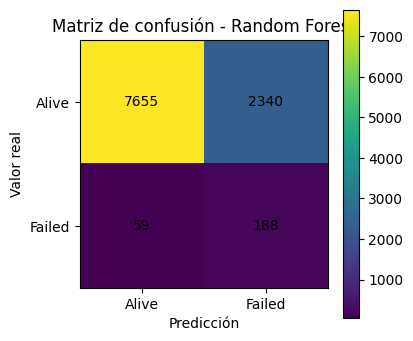

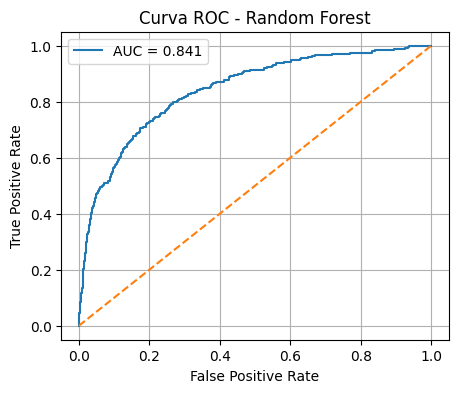

In [80]:
# ============================================================
# ANÁLISIS DEL MEJOR MODELO CLÁSICO
# Usando el threshold seleccionado en validation
# ============================================================

# Comprobación previa
print("Modelos disponibles en mejores_modelos:")
print(list(mejores_modelos.keys()))

print("\nThresholds disponibles en mejores_thresholds_ml:")
print(mejores_thresholds_ml)

print("\nModelos en tabla_resultados_test_ml:")
print(tabla_resultados_test_ml["Modelo"].tolist())

# ------------------------------------------------------------
# 1. Identificar mejor modelo según tabla de test
# ------------------------------------------------------------

mejor_nombre_ml = tabla_resultados_test_ml.iloc[0]["Modelo"]

# Por seguridad, convertir a string si fuera necesario
mejor_nombre_ml = str(mejor_nombre_ml)

print("\nMejor modelo clásico según el criterio Recall/FN/F1:", mejor_nombre_ml)

# ------------------------------------------------------------
# 2. Recuperar modelo y threshold
# ------------------------------------------------------------

if mejor_nombre_ml not in mejores_modelos:
    raise KeyError(
        f"El modelo '{mejor_nombre_ml}' no está en mejores_modelos. "
        f"Claves disponibles: {list(mejores_modelos.keys())}"
    )

if mejor_nombre_ml not in mejores_thresholds_ml:
    raise KeyError(
        f"El modelo '{mejor_nombre_ml}' no está en mejores_thresholds_ml. "
        f"Claves disponibles: {list(mejores_thresholds_ml.keys())}"
    )

mejor_modelo_ml = mejores_modelos[mejor_nombre_ml]
threshold_ml = float(mejores_thresholds_ml[mejor_nombre_ml])

print("Threshold seleccionado en validation:", round(threshold_ml, 4))

# ------------------------------------------------------------
# 3. Obtener probabilidades/scores en test
# ------------------------------------------------------------

y_proba_ml = obtener_scores_ml(mejor_modelo_ml, X_test_ml)

# ------------------------------------------------------------
# 4. Predicciones con threshold dinámico
# ------------------------------------------------------------

y_pred_ml = (y_proba_ml >= threshold_ml).astype(int)

# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_ml,
    target_names=["Alive", "Failed"],
    zero_division=0
))

# ------------------------------------------------------------
# 6. Matriz de confusión y curva ROC
# ------------------------------------------------------------

mostrar_matriz_confusion(mejor_nombre_ml, y_test, y_pred_ml)
plot_roc_curve(mejor_nombre_ml, y_test, y_proba_ml)

### Curvas Roc Comparativas - Modelos Deep Learning En Test

Genera las curvas ROC comparativas de los modelos de Deep Learning.

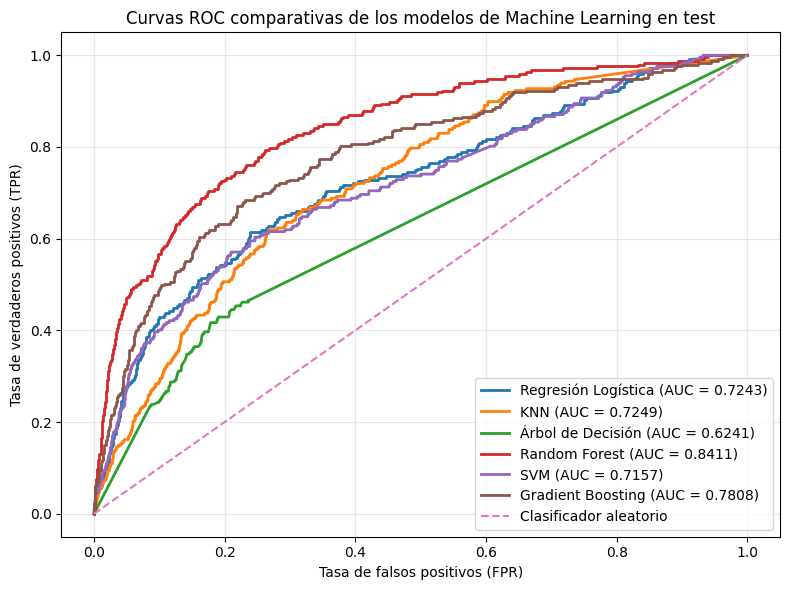

In [79]:
# ============================================================
# CURVAS ROC COMPARATIVAS - MODELOS DE MACHINE LEARNING EN TEST
# ============================================================

os.makedirs("figures", exist_ok=True)

orden_modelos_ml = [
    "Regresión Logística",
    "KNN",
    "Árbol de Decisión",
    "Random Forest",
    "SVM",
    "Gradient Boosting"
]

plt.figure(figsize=(8, 6))

for nombre_modelo in orden_modelos_ml:

    modelo = mejores_modelos[nombre_modelo]

    y_test_proba = modelo.predict_proba(X_test_ml)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombre_modelo} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC comparativas de los modelos de Machine Learning en test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("figures/curvas_roc_machine_learning_test.png", dpi=300, bbox_inches="tight")

plt.show()

### Gráfica: Comparación De Falsos Negativos - Machine Learning

Compara los falsos negativos de modelos clásicos y modelos de Deep Learning.

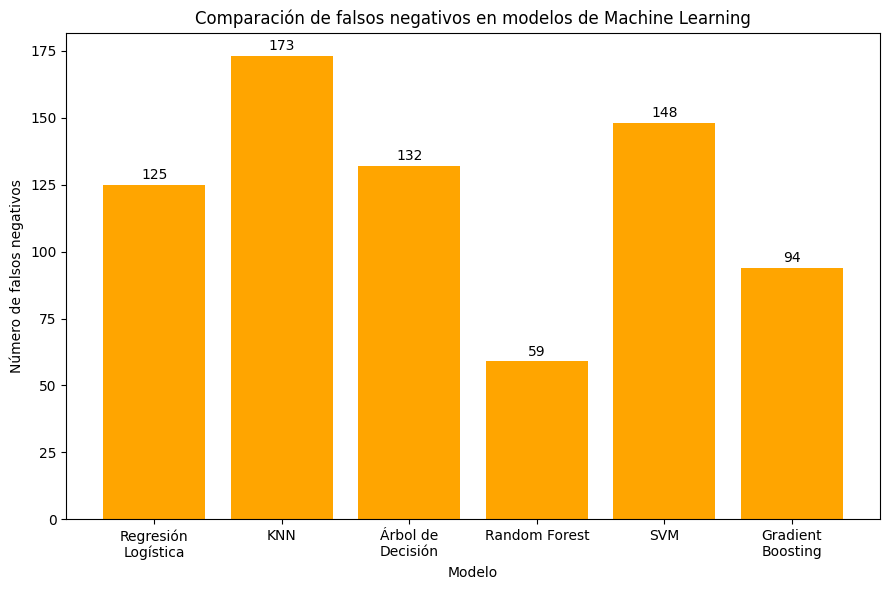

In [89]:
# ============================================================
# GRÁFICA: COMPARACIÓN DE FALSOS NEGATIVOS - MACHINE LEARNING
# ============================================================

import os
import textwrap
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Orden metodológico de los modelos de ML
orden_modelos_ml = [
    "Regresión Logística",
    "KNN",
    "Árbol de Decisión",
    "Random Forest",
    "SVM",
    "Gradient Boosting"
]

# Reordenar tabla según metodología
tabla_fn_ml = tabla_resultados_test_ml.set_index("Modelo").loc[orden_modelos_ml].reset_index()

# Crear etiquetas partidas en varias líneas si son largas
etiquetas_modelos = [
    textwrap.fill(modelo, width=14)
    for modelo in tabla_fn_ml["Modelo"]
]

plt.figure(figsize=(9, 6))

plt.bar(
    etiquetas_modelos,
    tabla_fn_ml["FN"],
    color="orange"
)

plt.title("Comparación de falsos negativos en modelos de Machine Learning")
plt.xlabel("Modelo")
plt.ylabel("Número de falsos negativos")

# Mantener etiquetas a 0 grados
plt.xticks(rotation=0, ha="center")

# Añadir valores encima de las barras
for i, valor in enumerate(tabla_fn_ml["FN"]):
    plt.text(
        i,
        valor + 1,
        str(int(valor)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "figures/comparacion_falsos_negativos_ml.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### MODELOS DE DEEP LEARNING


### Normalización Para Deep Learning

Prepara los datos en formato secuencial para las arquitecturas recurrentes.


In [42]:
# ============================================================
# NORMALIZACIÓN PARA DEEP LEARNING
# ============================================================


def escalar_datos_3d(X_train, X_val, X_test):
    """
    Escala datos 3D para redes recurrentes.

    Formato de entrada:
    samples, timesteps, features

    El scaler se ajusta SOLO con train.
    """

    n_train, timesteps, n_features = X_train.shape
    n_val = X_val.shape[0]
    n_test = X_test.shape[0]

    scaler = StandardScaler()

    # Convertimos train de 3D a 2D para ajustar scaler
    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    # Transformamos train, validation y test
    X_train_scaled = scaler.transform(
        X_train.reshape(-1, n_features)
    ).reshape(n_train, timesteps, n_features)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(n_val, timesteps, n_features)

    X_test_scaled = scaler.transform(
        X_test.reshape(-1, n_features)
    ).reshape(n_test, timesteps, n_features)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


X_train_dl_scaled, X_val_dl_scaled, X_test_dl_scaled, scaler_dl = escalar_datos_3d(
    X_train_dl_bal,
    X_val_dl,
    X_test_dl
)

print("Datos escalados para Deep Learning:")
print("X_train_dl_scaled:", X_train_dl_scaled.shape)
print("X_val_dl_scaled:  ", X_val_dl_scaled.shape)
print("X_test_dl_scaled: ", X_test_dl_scaled.shape)


Datos escalados para Deep Learning:
X_train_dl_scaled: (34225, 4, 18)
X_val_dl_scaled:   (8224, 4, 18)
X_test_dl_scaled:  (10242, 4, 18)


### Modelos de Deep Learning y optimización de hiperparámetros

### Funciones Para Crear Modelos Deep Learning

Define funciones auxiliares para crear y entrenar arquitecturas recurrentes.


In [44]:
# ============================================================
# FUNCIONES PARA CREAR MODELOS DEEP LEARNING
# ============================================================

timesteps = X_train_dl_scaled.shape[1]
n_features = X_train_dl_scaled.shape[2]

print("Timesteps:", timesteps)
print("Número de variables financieras:", n_features)


def crear_modelo_recurrente(
    tipo_modelo,
    timesteps,
    n_features,
    units_1=64,
    units_2=None,
    dense_units=32,
    dropout=0.3,
    learning_rate=0.001,
    l2_value=0.0001
):
    """
    Crea una red RNN, LSTM o GRU para clasificación binaria.
     Funciones de activación:
    - tanh en las capas recurrentes.
    - sigmoid en las compuertas internas de LSTM y GRU.
    - relu en la capa densa intermedia.
    - sigmoid en la capa final para obtener probabilidad de quiebra.
        Parámetros principales:
    - units_1: unidades recurrentes de la primera capa.
    - units_2: unidades recurrentes de la segunda capa. Si es None, se usa una sola capa.
    - dense_units: neuronas de la capa densa posterior.
    - dropout: regularización.
    - learning_rate: tasa de aprendizaje del optimizador Adam.
    - l2_value: regularización L2.
    """

    if tipo_modelo == "RNN":
        capa_recurrente = SimpleRNN
    elif tipo_modelo == "LSTM":
        capa_recurrente = LSTM
    elif tipo_modelo == "GRU":
        capa_recurrente = GRU
    else:
        raise ValueError("tipo_modelo debe ser 'RNN', 'LSTM' o 'GRU'.")

    model = Sequential(name=f"{tipo_modelo}_model")

    if units_2 is None:
        model.add(capa_recurrente(
            units=units_1,
            activation="tanh",
            input_shape=(timesteps, n_features),
            kernel_regularizer=l2(l2_value)
        ))
    else:
        model.add(capa_recurrente(
            units=units_1,
            activation="tanh",
            return_sequences=True,
            input_shape=(timesteps, n_features),
            kernel_regularizer=l2(l2_value)
        ))
        model.add(Dropout(dropout))
        model.add(capa_recurrente(
            units=units_2,
            activation="tanh",
            kernel_regularizer=l2(l2_value)
        ))

    model.add(Dropout(dropout))
    model.add(Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=l2(l2_value)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc", curve="ROC"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


def crear_modelo_multihead_lstm(
    timesteps,
    n_features,
    n_heads=3,
    head_units=32,
    dense_units=64,
    dropout=0.3,
    learning_rate=0.001,
    l2_value=0.0001
):
    """
    Crea una arquitectura Multi-Head LSTM coherente con la metodología.

    Cada cabeza LSTM procesa la misma secuencia financiera completa:
    (timesteps, n_features).

    Después se concatenan las representaciones aprendidas por cada cabeza y
    se aplica una capa densa antes de la salida sigmoide.
    """

    entrada = Input(shape=(timesteps, n_features), name="secuencia_financiera")

    heads = []

    for k in range(n_heads):
        h = LSTM(
            units=head_units,
            activation="tanh",
            kernel_regularizer=l2(l2_value),
            name=f"lstm_head_{k+1}"
        )(entrada)

        h = Dropout(dropout, name=f"dropout_head_{k+1}")(h)
        heads.append(h)

    if n_heads == 1:
        x = heads[0]
    else:
        x = Concatenate(name="concatenacion_cabezas")(heads)

    x = Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=l2(l2_value),
        name="capa_densa"
    )(x)
    x = BatchNormalization(name="batch_norm")(x)
    x = Dropout(dropout, name="dropout_denso")(x)

    salida = Dense(1, activation="sigmoid", name="salida_quiebra")(x)

    model = Model(inputs=entrada, outputs=salida, name="MultiHead_LSTM")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc", curve="ROC"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


Timesteps: 4
Número de variables financieras: 18


### Grid Search Para Deep Learning

Ejecuta la búsqueda de hiperparámetros de los modelos de Deep Learning.


In [54]:
# ============================================================
# GRID SEARCH PARA DEEP LEARNING
# ============================================================

# El Grid Search se realiza con train y validation.
# El conjunto de test queda reservado exclusivamente para la evaluación final.

# Se usa un número máximo alto de épocas, pero EarlyStopping detiene
# cada entrenamiento si el modelo deja de mejorar en validación.
MAX_EPOCHS = 120
PATIENCE_EARLY_STOPPING = 8

# Threshold usado SOLO para calcular métricas orientativas en validación.
# La selección del mejor modelo se hace por AUC de validación.
# El threshold final para reducir FN se ajustará posteriormente usando validation.
THRESHOLD_VALIDACION = 0.35

# Métrica principal para elegir la mejor configuración.
# En un problema desbalanceado, ROC-AUC es adecuada porque mide capacidad discriminante
# y no depende de un único threshold.
METRICA_SELECCION = "val_auc"


def crear_callbacks():
    """
    Crea callbacks nuevos para cada entrenamiento.
    Importante: no se deben reutilizar callbacks entre modelos.

    Se usa EarlyStopping sobre val_auc para conservar la configuración
    que mejor discrimina entre empresas activas y quebradas en validación.
    """

    early_stopping = EarlyStopping(
        monitor=METRICA_SELECCION,
        patience=PATIENCE_EARLY_STOPPING,
        mode="max",
        restore_best_weights=True,
        verbose=0
    )

    return [early_stopping]


def crear_grid(param_grid):
    """
    Convierte un diccionario de listas en una lista de configuraciones.
    Es un Grid Search explícito y fácil de entender.
    """

    claves = list(param_grid.keys())
    valores = list(param_grid.values())

    configs = []
    for combinacion in itertools.product(*valores):
        config = dict(zip(claves, combinacion))
        configs.append(config)

    return configs


# ------------------------------------------------------------
# Grids de hiperparámetros ajustados a la metodología
# ------------------------------------------------------------
# Están alineados con el apartado 3.4:
# - número de unidades recurrentes
# - número de capas recurrentes
# - capa densa posterior
# - dropout
# - batch size
# - tasa de aprendizaje
# - regularización L2
# - número de cabezas en Multi-Head LSTM
#
# No se incluye la función de activación en el grid porque queda fijada
# metodológicamente:
# - tanh en las capas recurrentes
# - sigmoid en compuertas LSTM/GRU y salida final
# - relu en la capa densa intermedia
#
# El tamaño de ventana temporal tampoco se incluye aquí porque ya se define
# antes al construir las secuencias.

grids_dl = {

    "RNN": {
        # Número de unidades recurrentes
        "units_1": [32, 64],

        # Número de capas:
        # None = una capa recurrente
        # 32 = segunda capa recurrente
        "units_2": [None, 32],

        # Capa densa posterior
        "dense_units": [32],

        # Regularización moderada
        "dropout": [0.1, 0.2, 0.3],

        # Tasas de aprendizaje razonables para Adam
        "learning_rate": [0.001, 0.0005],

        # Regularización L2 suave y moderada
        "l2_value": [0.0001, 0.001],

        # Tamaño del lote
        "batch_size": [32, 64]
    },

    "LSTM": {
        # Número de unidades LSTM
        "units_1": [64, 128],

        # Número de capas:
        # None = una capa LSTM
        # 64 = segunda capa LSTM
        "units_2": [None, 64],

        # Capa densa posterior
        "dense_units": [32, 64],

        # Mayor regularización para reducir overfitting
        "dropout": [0.2, 0.3, 0.4],

        # Tasas de aprendizaje
        "learning_rate": [0.001, 0.0005, 0.0001],

        # Regularización L2 suave y moderada
        "l2_value": [0.0001, 0.001],

        # Tamaño del lote
        "batch_size": [32, 64]
    },

    "GRU": {
        # Número de unidades GRU
        "units_1": [64, 128],

        # Número de capas:
        # None = una capa GRU
        # 64 = segunda capa GRU
        "units_2": [None, 64],

        # Capa densa posterior
        "dense_units": [32, 64],

        # Mayor regularización para reducir overfitting
        "dropout": [0.2, 0.3, 0.4],

        # Tasas de aprendizaje
        "learning_rate": [0.001, 0.0005, 0.0001],

        # Regularización L2 suave y moderada
        "l2_value": [0.0001, 0.001],

        # Tamaño del lote
        "batch_size": [32, 64]
    },

    "Multi-Head LSTM": {
        # Número de cabezas recurrentes
        "n_heads": [2, 3],

        # Unidades LSTM por cabeza
        "head_units": [32, 64],

        # Capa densa tras concatenar las cabezas
        # Se deja en 64 para evitar excesiva complejidad
        "dense_units": [64],

        # Mayor regularización porque es la arquitectura con más parámetros
        "dropout": [0.3, 0.4],

        # Tasas de aprendizaje razonables para Adam
        "learning_rate": [0.001, 0.0005],

        # Regularización L2 suave y moderada
        "l2_value": [0.0001, 0.001],

        # Tamaño del lote
        "batch_size": [32, 64]
    }
}


# ------------------------------------------------------------
# Comprobación del tamaño del Grid Search
# ------------------------------------------------------------

print("Número de configuraciones por modelo:")
total_configs = 0

for nombre_modelo, param_grid in grids_dl.items():
    n_configs = len(crear_grid(param_grid))
    total_configs += n_configs
    print(f"{nombre_modelo}: {n_configs} configuraciones")

print(f"\nTotal configuraciones Deep Learning: {total_configs}")


# ------------------------------------------------------------
# Control opcional para reducir o ampliar la búsqueda
# ------------------------------------------------------------
# Para una ejecución completa, deja MAX_CONFIGS_PER_MODEL = None.
# Para probar que todo funciona rápido, usa por ejemplo 2 o 3.

MAX_CONFIGS_PER_MODEL = None


mejores_modelos_dl = {}
mejores_configs_dl = {}
histories = {}
resultados_val_dl = []
resultados_grid_dl = []


for nombre_modelo, param_grid in grids_dl.items():

    lista_configs = crear_grid(param_grid)

    if MAX_CONFIGS_PER_MODEL is not None:
        lista_configs = lista_configs[:MAX_CONFIGS_PER_MODEL]

    print("=" * 90)
    print(f"GRID SEARCH - {nombre_modelo}")
    print(f"Número de configuraciones: {len(lista_configs)}")

    mejor_auc_val = -1
    mejor_modelo = None
    mejor_config = None
    mejor_history = None

    tiempo_inicio_modelo = time.time()

    for i, config in enumerate(lista_configs, start=1):

        print("-" * 90)
        print(f"{nombre_modelo} | Configuración {i}/{len(lista_configs)}")
        print(config)

        # Extraemos batch_size porque no forma parte de la arquitectura.
        batch_size = config["batch_size"]
        config_modelo = {k: v for k, v in config.items() if k != "batch_size"}

        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)

        if nombre_modelo == "Multi-Head LSTM":
            modelo = crear_modelo_multihead_lstm(
                timesteps=timesteps,
                n_features=n_features,
                **config_modelo
            )
        else:
            modelo = crear_modelo_recurrente(
                tipo_modelo=nombre_modelo,
                timesteps=timesteps,
                n_features=n_features,
                **config_modelo
            )

        tiempo_inicio_config = time.time()

        history = modelo.fit(
            X_train_dl_scaled,
            y_train_bal,
            validation_data=(X_val_dl_scaled, y_val),
            epochs=MAX_EPOCHS,
            batch_size=batch_size,
            callbacks=crear_callbacks(),
            verbose=0
        )

        tiempo_config = time.time() - tiempo_inicio_config

        # Predicción de probabilidades en validation
        y_val_proba = modelo.predict(X_val_dl_scaled, verbose=0).ravel()

        # Conversión a clase usando threshold orientativo de validación
        y_val_pred = (y_val_proba >= THRESHOLD_VALIDACION).astype(int)

        # Métricas de validación
        # AUC no depende del threshold; el resto sí.
        auc_val = roc_auc_score(y_val, y_val_proba)
        acc_val = accuracy_score(y_val, y_val_pred)
        precision_val = precision_score(y_val, y_val_pred, zero_division=0)
        recall_val = recall_score(y_val, y_val_pred, zero_division=0)
        f1_val = f1_score(y_val, y_val_pred, zero_division=0)

        n_epochs_real = len(history.history["loss"])

        fila_resultado = {
            "Modelo": nombre_modelo,
            "Configuracion": i,
            "Threshold_validacion": THRESHOLD_VALIDACION,
            "AUC_val": auc_val,
            "Accuracy_val": acc_val,
            "Precision_val": precision_val,
            "Recall_val": recall_val,
            "F1_val": f1_val,
            "Epochs_entrenadas": n_epochs_real,
            "Tiempo_segundos": round(tiempo_config, 2),
            **config
        }

        resultados_grid_dl.append(fila_resultado)

        print(
            f"AUC val: {auc_val:.4f} | "
            f"Recall val: {recall_val:.4f} | "
            f"F1 val: {f1_val:.4f} | "
            f"Threshold val: {THRESHOLD_VALIDACION:.2f} | "
            f"Epochs: {n_epochs_real} | "
            f"Tiempo: {tiempo_config/60:.2f} min"
        )

        # Selección del mejor modelo por AUC de validación.
        # Esto es correcto porque el AUC mide capacidad discriminante
        # y no depende de un único threshold.
        if auc_val > mejor_auc_val:
            mejor_auc_val = auc_val
            mejor_modelo = modelo
            mejor_config = config
            mejor_history = history

    tiempo_total_modelo = time.time() - tiempo_inicio_modelo

    mejores_modelos_dl[nombre_modelo] = mejor_modelo
    mejores_configs_dl[nombre_modelo] = mejor_config
    histories[nombre_modelo] = mejor_history

    resultados_val_dl.append({
        "Modelo": nombre_modelo,
        "Mejor AUC Validation": mejor_auc_val,
        "Mejor configuración": mejor_config,
        "Threshold validación": THRESHOLD_VALIDACION,
        "Tiempo total minutos": round(tiempo_total_modelo / 60, 2)
    })


tabla_gridsearch_dl = pd.DataFrame(resultados_grid_dl)
tabla_resultados_val_dl = pd.DataFrame(resultados_val_dl)

tabla_resultados_val_dl = tabla_resultados_val_dl.sort_values(
    by="Mejor AUC Validation",
    ascending=False
)

display(tabla_resultados_val_dl)

print("\nMejores configuraciones encontradas:")
for modelo, config in mejores_configs_dl.items():
    print("\n", modelo)
    print(config)

# Guardar resultados para poder documentarlos en el TFM
tabla_gridsearch_dl.to_csv("resultados_gridsearch_deep_learning.csv", index=False)
tabla_resultados_val_dl.to_csv("mejores_configuraciones_deep_learning.csv", index=False)


Número de configuraciones por modelo:
RNN: 96 configuraciones
LSTM: 288 configuraciones
GRU: 288 configuraciones
Multi-Head LSTM: 64 configuraciones

Total configuraciones Deep Learning: 736
GRID SEARCH - RNN
Número de configuraciones: 96
------------------------------------------------------------------------------------------
RNN | Configuración 1/96
{'units_1': 32, 'units_2': None, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'l2_value': 0.0001, 'batch_size': 32}


C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AUC val: 0.7965 | Recall val: 0.9072 | F1 val: 0.1369 | Threshold val: 0.35 | Epochs: 30 | Tiempo: 0.91 min
------------------------------------------------------------------------------------------
RNN | Configuración 2/96
{'units_1': 32, 'units_2': None, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'l2_value': 0.0001, 'batch_size': 64}


C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AUC val: 0.7854 | Recall val: 0.9253 | F1 val: 0.1195 | Threshold val: 0.35 | Epochs: 14 | Tiempo: 0.22 min
------------------------------------------------------------------------------------------
RNN | Configuración 3/96
{'units_1': 32, 'units_2': None, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'l2_value': 0.001, 'batch_size': 32}


...

AUC val: 0.7756 | Recall val: 0.9433 | F1 val: 0.1081 | Threshold val: 0.35 | Epochs: 18 | Tiempo: 9.11 min
------------------------------------------------------------------------------------------
GRU | Configuración 288/288
{'units_1': 128, 'units_2': 64, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.0001, 'l2_value': 0.001, 'batch_size': 64}


C:\Users\Propietario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AUC val: 0.7733 | Recall val: 0.9485 | F1 val: 0.1082 | Threshold val: 0.35 | Epochs: 25 | Tiempo: 8.57 min
GRID SEARCH - Multi-Head LSTM
Número de configuraciones: 64
------------------------------------------------------------------------------------------
Multi-Head LSTM | Configuración 1/64
{'n_heads': 2, 'head_units': 32, 'dense_units': 64, 'dropout': 0.3, 'learning_rate': 0.001, 'l2_value': 0.0001, 'batch_size': 32}
AUC val: 0.7759 | Recall val: 0.8969 | F1 val: 0.1188 | Threshold val: 0.35 | Epochs: 14 | Tiempo: 2.45 min
------------------------------------------------------------------------------------------
Multi-Head LSTM | Configuración 2/64
{'n_heads': 2, 'head_units': 32, 'dense_units': 64, 'dropout': 0.3, 'learning_rate': 0.001, 'l2_value': 0.0001, 'batch_size': 64}
AUC val: 0.7855 | Recall val: 0.9253 | F1 val: 0.1196 | Threshold val: 0.35 | Epochs: 11 | Tiempo: 1.86 min
------------------------------------------------------------------------------------------
Multi-Hea

,Modelo,Mejor AUC Validation,Mejor configuración,Threshold validación,Tiempo total minutos
0,RNN,0.801787,"{'units_1': 64, 'units_2': 32, 'dense_units': ...",0.35,71.16
3,Multi-Head LSTM,0.796604,"{'n_heads': 3, 'head_units': 32, 'dense_units'...",0.35,233.47
2,GRU,0.796102,"{'units_1': 64, 'units_2': None, 'dense_units'...",0.35,806.80
1,LSTM,0.792943,"{'units_1': 128, 'units_2': None, 'dense_units...",0.35,432.81



Mejores configuraciones encontradas:

 RNN
{'units_1': 64, 'units_2': 32, 'dense_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'l2_value': 0.0001, 'batch_size': 32}

 LSTM
{'units_1': 128, 'units_2': None, 'dense_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'l2_value': 0.001, 'batch_size': 32}

 GRU
{'units_1': 64, 'units_2': None, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.0005, 'l2_value': 0.0001, 'batch_size': 32}

 Multi-Head LSTM
{'n_heads': 3, 'head_units': 32, 'dense_units': 64, 'dropout': 0.3, 'learning_rate': 0.0005, 'l2_value': 0.001, 'batch_size': 64}


### Evaluación Final Deep Learning Con Ajuste De Threshold

Evalúa los modelos recurrentes sobre validación y selecciona umbrales de decisión.


In [107]:
# ============================================================
# EVALUACIÓN FINAL DEEP LEARNING CON AJUSTE DE THRESHOLD
# Objetivo: reducir falsos negativos (FN)
# ============================================================

def buscar_umbral_reducir_fn(y_true, y_proba, precision_minima=0.15):
    """
    Busca el umbral usando SOLO el conjunto de validación.

    Objetivo principal:
    - Maximizar recall para reducir falsos negativos (FN).

    Control mínimo:
    - Exigir una precision mínima para evitar que el modelo clasifique
      prácticamente todas las empresas como quebradas.
    """

    thresholds = np.arange(0.05, 0.95, 0.01)

    resultados = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        resultados.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    tabla_thresholds = pd.DataFrame(resultados)

    # Nos quedamos con umbrales que mantienen una precisión mínima
    candidatos = tabla_thresholds[
        tabla_thresholds["Precision"] >= precision_minima
    ].copy()

    # Si ningún umbral cumple la precisión mínima, usamos todos
    if candidatos.empty:
        candidatos = tabla_thresholds.copy()

    # Elegimos:
    # 1º mayor recall
    # 2º menor FN
    # 3º mayor F1-score
    candidatos = candidatos.sort_values(
        by=["Recall", "FN", "F1-score"],
        ascending=[False, True, False]
    )

    mejor_fila = candidatos.iloc[0]
    mejor_threshold = mejor_fila["Threshold"]

    return mejor_threshold, tabla_thresholds


def evaluar_dl_final(nombre_modelo, modelo, X_val, y_val, X_test, y_test, precision_minima=0.15):
    """
    Evaluación final del modelo:
    1. Predice probabilidades en validación.
    2. Selecciona el threshold en validación.
    3. Evalúa el modelo en test usando ese threshold.
    """

    # -----------------------------
    # 1. Probabilidades en validación
    # -----------------------------
    y_val_proba = modelo.predict(X_val, verbose=0).ravel()

    mejor_threshold, tabla_thresholds = buscar_umbral_reducir_fn(
        y_true=y_val,
        y_proba=y_val_proba,
        precision_minima=precision_minima
    )

    # -----------------------------
    # 2. Evaluación final en test
    # -----------------------------
    y_test_proba = modelo.predict(X_test, verbose=0).ravel()
    y_test_pred = (y_test_proba >= mejor_threshold).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_test_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    error_tipo_i = fp / (fp + tn) if (fp + tn) > 0 else 0
    error_tipo_ii = fn / (fn + tp) if (fn + tp) > 0 else 0

    resultado = {
        "Modelo": nombre_modelo,
        "Threshold": mejor_threshold,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Error Tipo I": error_tipo_i,
        "Error Tipo II": error_tipo_ii
    }

    return resultado, tabla_thresholds


# ============================================================
# APLICAR A TODOS LOS MODELOS DEEP LEARNING
# ============================================================

PRECISION_MINIMA = 0.15

resultados_test_dl = []
tablas_thresholds_dl = {}

for nombre_modelo, modelo in mejores_modelos_dl.items():

    print("=" * 70)
    print("Evaluando modelo Deep Learning:", nombre_modelo)

    resultado, tabla_thresholds = evaluar_dl_final(
        nombre_modelo=nombre_modelo,
        modelo=modelo,
        X_val=X_val_dl_scaled,
        y_val=y_val,
        X_test=X_test_dl_scaled,
        y_test=y_test,
        precision_minima=PRECISION_MINIMA
    )

    resultados_test_dl.append(resultado)
    tablas_thresholds_dl[nombre_modelo] = tabla_thresholds

tabla_resultados_test_dl = pd.DataFrame(resultados_test_dl)

tabla_resultados_test_dl = tabla_resultados_test_dl.sort_values(
    by=["Recall", "FN", "F1-score", "ROC-AUC"],
    ascending=[False, True, False, False]
)

display(tabla_resultados_test_dl)

tabla_resultados_test_dl.to_csv(
    "resultados_test_deep_learning_threshold_recall.csv",
    index=False
)


Evaluando modelo Deep Learning: RNN
Evaluando modelo Deep Learning: LSTM
Evaluando modelo Deep Learning: GRU
Evaluando modelo Deep Learning: Multi-Head LSTM


,Modelo,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,Error Tipo I,Error Tipo II
3,Multi-Head LSTM,0.57,0.788908,0.070049,0.631579,0.126112,0.790550,7924,2071,91,156,0.207204,0.368421
1,LSTM,0.58,0.775532,0.065622,0.627530,0.118819,0.785075,7788,2207,92,155,0.220810,0.372470
2,GRU,0.53,0.783245,0.067135,0.619433,0.121140,0.782551,7869,2126,94,153,0.212706,0.380567
0,RNN,0.63,0.789104,0.066606,0.595142,0.119804,0.786365,7935,2060,100,147,0.206103,0.404858


### Celda 51: Bloque de análisis

Evalúa los modelos clásicos de Machine Learning en el conjunto de test.


In [101]:
# ============================================================
# NOTA METODOLÓGICA
# ============================================================

# Esta celda sustituía anteriormente la evaluación de Machine Learning con threshold fijo = 0.5.
# Se deja anulada para evitar sobrescribir tabla_resultados_test_ml.
#
# La evaluación correcta de Machine Learning ya se ha realizado antes mediante:
# - selección del threshold en validation;
# - aplicación de ese mismo threshold en test;
# - ordenación por Recall, FN, F1-score y ROC-AUC.


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,Error Tipo I,Error Tipo II
3,Random Forest,0.974517,0.354167,0.068826,0.115254,0.839566,9964,31,230,17,0.003102,0.931174
5,Gradient Boosting,0.900020,0.114201,0.465587,0.183413,0.780723,9103,892,132,115,0.089245,0.534413
1,KNN,0.661394,0.047231,0.680162,0.088328,0.730715,6606,3389,79,168,0.339070,0.319838
0,Regresión Logística,0.432533,0.032902,0.793522,0.063185,0.724330,4234,5761,51,196,0.576388,0.206478
4,SVM,0.401972,0.031559,0.801619,0.060727,0.715689,3919,6076,49,198,0.607904,0.198381
2,Árbol de Decisión,0.824546,0.050985,0.356275,0.089204,0.626835,8357,1638,159,88,0.163882,0.643725


### Identificar Mejores Modelos Deep Learning Según Distintos Criterios

Identifica los mejores modelos de Deep Learning según ROC-AUC, recall, F1-score, falsos negativos y error tipo II.


In [108]:
# ============================================================
# IDENTIFICAR MEJORES MODELOS DEEP LEARNING SEGÚN DISTINTOS CRITERIOS
# ============================================================

# Usamos la tabla final de resultados de Deep Learning
tabla_final_dl = tabla_resultados_test_dl.copy()

mejor_auc = tabla_final_dl.sort_values("ROC-AUC", ascending=False).iloc[0]
mejor_recall = tabla_final_dl.sort_values("Recall", ascending=False).iloc[0]
mejor_f1 = tabla_final_dl.sort_values("F1-score", ascending=False).iloc[0]
menor_error_tipo_ii = tabla_final_dl.sort_values("Error Tipo II", ascending=True).iloc[0]
menor_fn = tabla_final_dl.sort_values("FN", ascending=True).iloc[0]

print("Resumen de resultados Deep Learning:")
print("------------------------------------")
print(f"Modelo con mayor ROC-AUC: {mejor_auc['Modelo']} ({mejor_auc['ROC-AUC']:.4f})")
print(f"Modelo con mayor Recall: {mejor_recall['Modelo']} ({mejor_recall['Recall']:.4f})")
print(f"Modelo con mayor F1-score: {mejor_f1['Modelo']} ({mejor_f1['F1-score']:.4f})")
print(f"Modelo con menor Error Tipo II: {menor_error_tipo_ii['Modelo']} ({menor_error_tipo_ii['Error Tipo II']:.4f})")
print(f"Modelo con menor número de FN: {menor_fn['Modelo']} ({int(menor_fn['FN'])} FN)")

print("\nInterpretación metodológica:")
print("En predicción de quiebra empresarial, el Recall, los FN y el Error Tipo II son especialmente importantes.")
print("Un falso negativo implica clasificar como activa una empresa que realmente quiebra.")
print("Por ello, la selección del modelo no debe basarse únicamente en Accuracy o ROC-AUC.")


Resumen de resultados Deep Learning:
------------------------------------
Modelo con mayor ROC-AUC: Multi-Head LSTM (0.7905)
Modelo con mayor Recall: Multi-Head LSTM (0.6316)
Modelo con mayor F1-score: Multi-Head LSTM (0.1261)
Modelo con menor Error Tipo II: Multi-Head LSTM (0.3684)
Modelo con menor número de FN: Multi-Head LSTM (91 FN)

Interpretación metodológica:
En predicción de quiebra empresarial, el Recall, los FN y el Error Tipo II son especialmente importantes.
Un falso negativo implica clasificar como activa una empresa que realmente quiebra.
Por ello, la selección del modelo no debe basarse únicamente en Accuracy o ROC-AUC.


### Matrices De Confusión - Todos Los Modelos Deep Learning

Genera matrices de confusión de los modelos de Deep Learning en test.


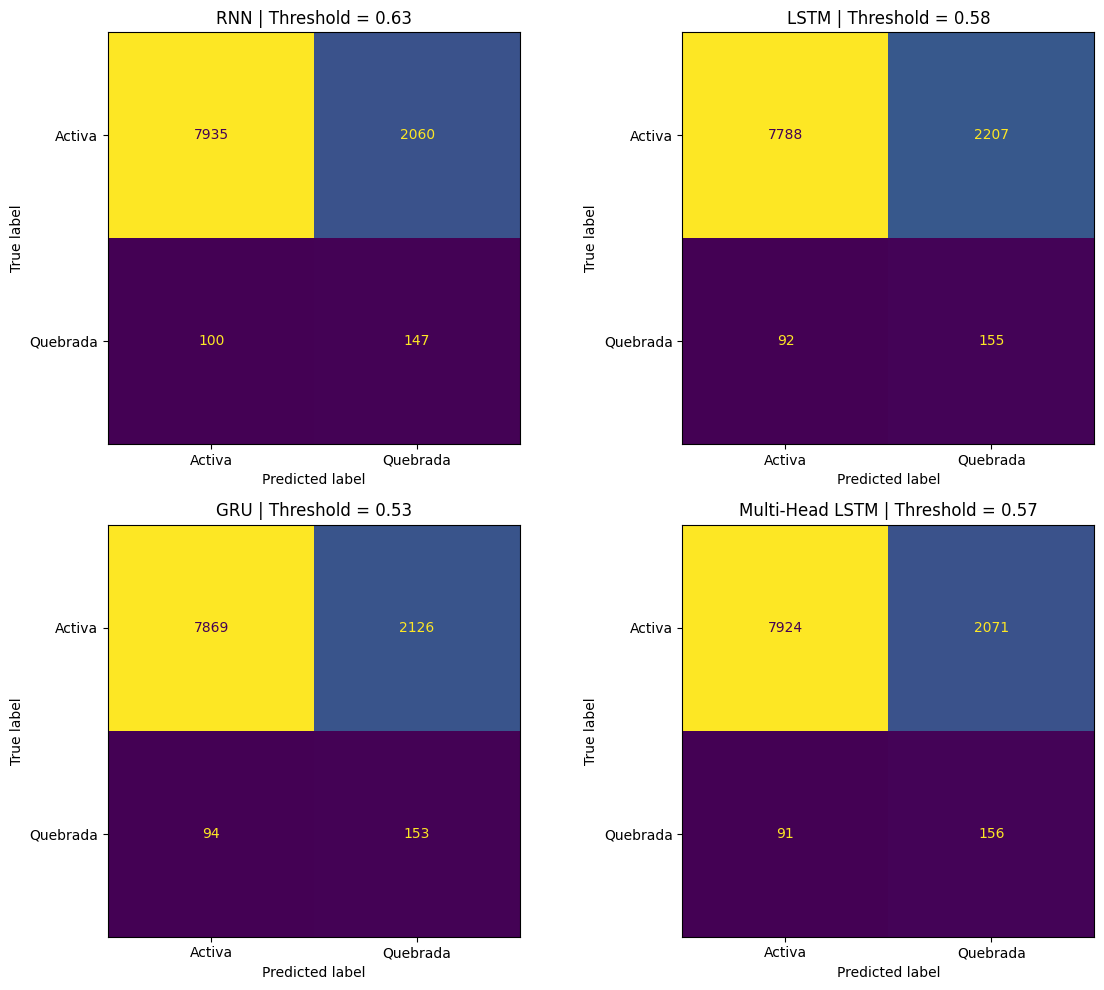

In [109]:
# ============================================================
# MATRICES DE CONFUSIÓN - TODOS LOS MODELOS DEEP LEARNING
# Usando el threshold seleccionado para cada modelo
# ============================================================


# Orden metodológico de los modelos
orden_modelos_dl = ["RNN", "LSTM", "GRU", "Multi-Head LSTM"]

# Crear figura conjunta
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, nombre_modelo in enumerate(orden_modelos_dl):

    # Recuperar modelo entrenado
    modelo = mejores_modelos_dl[nombre_modelo]

    # Recuperar threshold final seleccionado para ese modelo
    threshold_modelo = tabla_resultados_test_dl.loc[
        tabla_resultados_test_dl["Modelo"] == nombre_modelo,
        "Threshold"
    ].values[0]

    # Predicción de probabilidades en test
    y_test_proba = modelo.predict(X_test_dl_scaled, verbose=0).ravel()

    # Aplicar threshold seleccionado
    y_test_pred = (y_test_proba >= threshold_modelo).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_test_pred)

    # Dibujar matriz
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Activa", "Quebrada"]
    )

    disp.plot(
        ax=axes[i],
        values_format="d",
        colorbar=False
    )

    axes[i].set_title(f"{nombre_modelo} | Threshold = {threshold_modelo:.2f}")

plt.tight_layout()

# Guardar figura para Overleaf
plt.savefig("matrices_confusion_deep_learning.png", dpi=300, bbox_inches="tight")

plt.show()


### Curvas De Entrenamiento Deep Learning

Representa las curvas de entrenamiento de los modelos recurrentes.


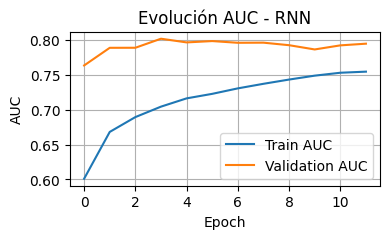

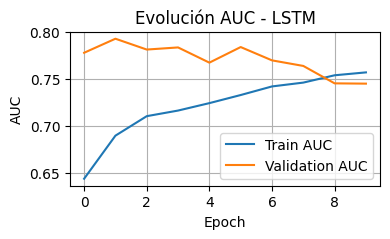

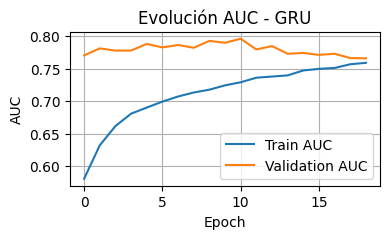

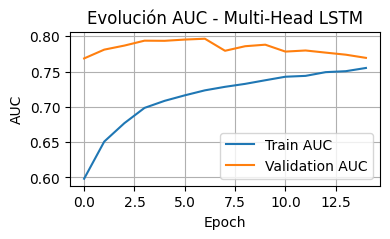

In [111]:
# ============================================================
# CURVAS DE ENTRENAMIENTO DEEP LEARNING
# ============================================================

for nombre, history in histories.items():

    plt.figure(figsize=(4, 2))

    plt.plot(history.history["auc"], label="Train AUC")
    plt.plot(history.history["val_auc"], label="Validation AUC")

    plt.title(f"Evolución AUC - {nombre}")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)
    plt.show()


### Curvas Roc Comparativas - Modelos Deep Learning En Test

Genera las curvas ROC comparativas de los modelos de Deep Learning.


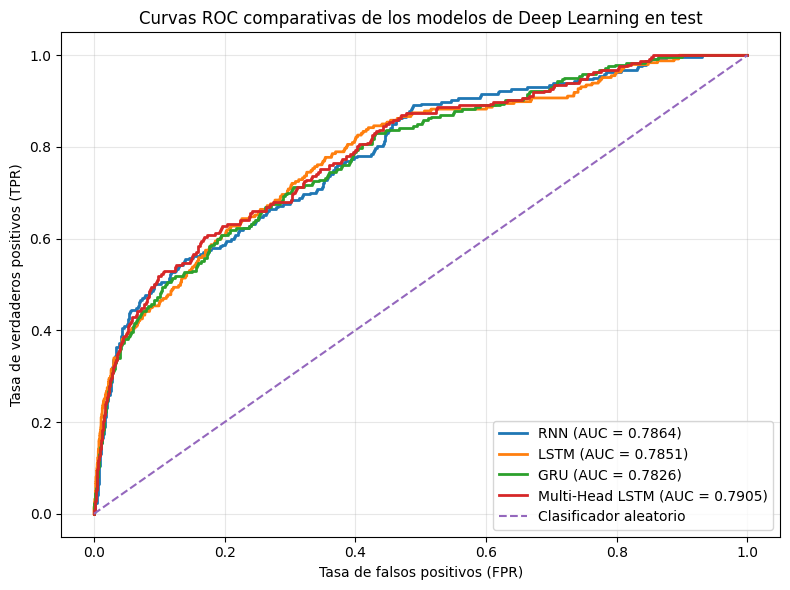

In [112]:

# ============================================================
# CURVAS ROC COMPARATIVAS - MODELOS DEEP LEARNING EN TEST
# ============================================================


orden_modelos_dl = ["RNN", "LSTM", "GRU", "Multi-Head LSTM"]

plt.figure(figsize=(8, 6))

for nombre_modelo in orden_modelos_dl:

    modelo = mejores_modelos_dl[nombre_modelo]

    # Probabilidades predichas en test
    y_test_proba = modelo.predict(X_test_dl_scaled, verbose=0).ravel()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombre_modelo} (AUC = {roc_auc:.4f})"
    )

# Línea diagonal de referencia
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC comparativas de los modelos de Deep Learning en test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Guardar para Overleaf
plt.savefig("curvas_roc_deep_learning_test.png", dpi=300, bbox_inches="tight")

plt.show()


### Gráfica: Comparación De Falsos Negativos - Deep Learning

Representa los falsos negativos de las arquitecturas recurrentes de Deep Learning.


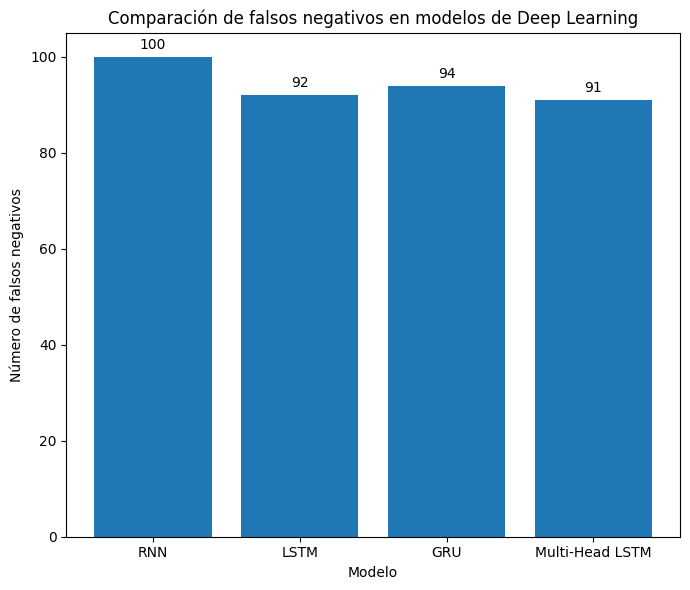

In [123]:
# ============================================================
# GRÁFICA: COMPARACIÓN DE FALSOS NEGATIVOS - DEEP LEARNING
# ============================================================


os.makedirs("figures", exist_ok=True)

# Orden metodológico de los modelos
orden_modelos_dl = ["RNN", "LSTM", "GRU", "Multi-Head LSTM"]

# Reordenar tabla según metodología
tabla_fn_dl = tabla_resultados_test_dl.set_index("Modelo").loc[orden_modelos_dl].reset_index()

plt.figure(figsize=(7,6))

plt.bar(
    tabla_fn_dl["Modelo"],
    tabla_fn_dl["FN"]
)

plt.title("Comparación de falsos negativos en modelos de Deep Learning")
plt.xlabel("Modelo")
plt.ylabel("Número de falsos negativos")

# Añadir valores encima de las barras
for i, valor in enumerate(tabla_fn_dl["FN"]):
    plt.text(
        i,
        valor + 1,
        str(int(valor)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("figures/comparacion_falsos_negativos.png", dpi=300, bbox_inches="tight")

plt.show()


### Análisis Del Mejor Modelo Deep Learning

Analiza con mayor detalle el mejor modelo de Deep Learning seleccionado.


Mejor modelo Deep Learning: Multi-Head LSTM

Threshold utilizado: 0.5700000000000002

Classification report:
              precision    recall  f1-score   support

       Alive       0.99      0.79      0.88      9995
      Failed       0.07      0.63      0.13       247

    accuracy                           0.79     10242
   macro avg       0.53      0.71      0.50     10242
weighted avg       0.97      0.79      0.86     10242



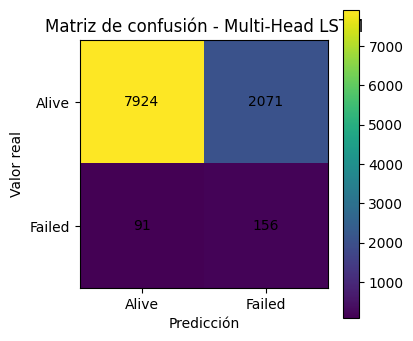

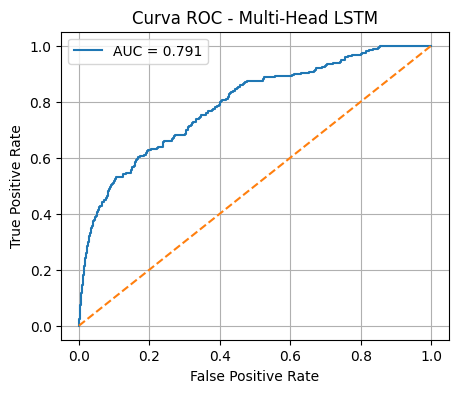

In [114]:
# S ============================================================
# ANÁLISIS DEL MEJOR MODELO DEEP LEARNING
# ============================================================

mejor_nombre_dl = tabla_resultados_test_dl.iloc[0]["Modelo"]
mejor_modelo_dl = mejores_modelos_dl[mejor_nombre_dl]

print("Mejor modelo Deep Learning:", mejor_nombre_dl)

y_proba_dl = mejor_modelo_dl.predict(X_test_dl_scaled, verbose=0).ravel()

threshold_dl = tabla_resultados_test_dl.iloc[0]["Threshold"]
y_pred_dl = (y_proba_dl >= threshold_dl).astype(int)

print("\nThreshold utilizado:", threshold_dl)

print("\nClassification report:")
print(classification_report(y_test, y_pred_dl, target_names=["Alive", "Failed"]))

mostrar_matriz_confusion(mejor_nombre_dl, y_test, y_pred_dl)
plot_roc_curve(mejor_nombre_dl, y_test, y_proba_dl)
